---

# Sparse Behavioral Prediction Analysis

**Research Question**: Do skarf and PySPI methods perform comparably when both are constrained to the same sparsity level?

**Motivation**: Skarf's methods and PySPI's methods have fundamentally different architectures. Imposing uniform 0.8 sparsity (retaining top 20% of connections) aims to isolate method quality from sparsity effects.

**Target**: Cognition factor (most predictable behavioral measure)

**Analyses**:
1. **Sparse vs Non-Sparse Comparison**: How does imposed sparsity affect methods with different natural sparsity?
   - Part A: Skarf methods (showing both lag=0 and lag=1)
      - Lag=0 vs Lag=1 comparison for skarf
   - Part B: PySPI methods
2. **Natural Sparsity vs Performance**: Is there a relationship between original sparsity and post-threshold performance?
3. **Top Performers**: Which methods rank highest under uniform sparsity?
4. **Distributions and Statistical Testing**: Do skarf and PySPI families differ significantly? (includes lag-specific tests)
5. **Stratified Analysis**: Within natural sparsity bins, do method families differ?
6. **Rank Correlation**: Are rankings preserved between non-sparse and sparse conditions?

**Updates**:
- Added lag=1 for skarf methods
- Changed natural sparsity calculation to use t=0.05 threshold
- Repeated the analysis after updating the `apply_sparsity` function to correctly handle symmetric matrices
---

In [1]:
import os
from pathlib import Path

from matplotlib import pyplot as plt
from matplotlib.patches import Patch
import numpy as np
import pandas as pd
from scipy.stats import spearmanr, wilcoxon, mannwhitneyu

from arfcexp.hcp import load_hcp_behav_factors_topk
from arfcexp.skarf_utils import AVAILABLE_SKARF_FUNCS
from skarf import set_cache_dir
from skarf.covariance import load_spi_config_map

In [2]:
pd.options.display.precision = 4

style_path = os.environ["MPL_STYLE"]
print("matplotlib style:", style_path)
plt.style.use(style_path)

color_cycle = plt.rcParams["axes.prop_cycle"].by_key()["color"]

PLOTW, _ = plt.rcParams["figure.figsize"]
FORMAT = plt.rcParams["savefig.format"]
print(PLOTW, FORMAT)

matplotlib style: /home/aerkent/skarf-experiments/resources/clane.mplstyle
3.42 png


In [3]:
project_root = Path(os.environ["PROJECT_ROOT"])

# Sparse prediction results (0.8 sparsity)
sparse_result_dir = (
    project_root / "results/hcp_1200_sparse_behav_prediction/sparsity-0.80__parc-200__pool-3__n-20__perm-0__seed-2142"
)

# Original non-sparse results for comparison
pyspi_result_dir = (
    project_root / "results/hcp_1200_pyspi_behav_prediction_factor_full"
)
skarf_result_dir = (
    project_root / "results/hcp_1200_skarf_behav_prediction_factor_full"
)

# Baseline results
baseline_result_dir = (
    project_root / "results/hcp_1200_pyspi_behav_prediction_all_targets_cov"
)

# Output directory
analysis_dir = project_root / "results/hcp_1200_sparse_behav_prediction_analysis"
analysis_dir.mkdir(exist_ok=True)

### Load method/function metadata

In [4]:
# Load mean sparsity data to get method/func IDs
mean_sparsity_path = "/srv/projects/skarf/sparsity_computation/mean_sparsity_by_function_all_thresholds.csv"
mean_sparsity_df = pd.read_csv(mean_sparsity_path)

# Create method/func lookup
# Use sparsity_t0.05_mean as natural sparsity (threshold at 0.05 instead of 0.00)
method_func_map = mean_sparsity_df[['method', 'func_id', 'func', 'sparsity_t0.05_mean']].copy()
method_func_map.columns = ['method', 'method_id', 'func', 'natural_sparsity_t005']

print(f"Total method/func combinations: {len(method_func_map)}")
method_func_map.head(10)

Total method/func combinations: 161


,method,method_id,func,natural_sparsity_t005
0,pyspi,38,xcorr_mean_sig-True,0.9950
1,pyspi,40,xcorr_mean_sig-False,0.9950
2,pyspi,67,bary_euclidean_mean,0.9950
3,pyspi,86,reci,0.9948
4,pyspi,135,te_symbolic_k-10_kt-1_l-1_lt-1,0.9950
5,pyspi,241,sgc_parametric_mean_fs-1_fmin-0-25_fmax-0-5_or...,0.9950
6,pyspi,250,sgc_parametric_max_fs-1_fmin-0-25_fmax-0-5_ord...,0.9950
7,pyspi,133,gc_gaussian_k-1_kt-1_l-1_lt-1,0.9920
8,pyspi,134,te_symbolic_k-1_kt-1_l-1_lt-1,0.9920
9,pyspi,239,sgc_parametric_mean_fs-1_fmin-1e-05_fmax-0-5_o...,0.9753


### Load SPI metadata

In [5]:
spi_list_dir = project_root / "resources/spi_lists"
set_cache_dir(spi_list_dir)

spi_config_map, _ = load_spi_config_map()

all_spis = (spi_list_dir / "spi_list_all_284.txt").read_text().strip().split()
spi_list = (spi_list_dir / "spi_list_select_300s_149.txt").read_text().strip().split()

spi_table = pd.DataFrame.from_records(
    [
        {"spi_id": idx, "spi": spi, **spi_config_map[spi]}
        for idx, spi in enumerate(all_spis)
    ]
)

spi_table.insert(
    2, "category", pd.Categorical([module.split(".")[-1] for module in spi_table["module_name"]])
)
spi_table.insert(3, "identifier", pd.Categorical([spi.split("_")[0] for spi in spi_table["spi"]]))
spi_table = spi_table.drop(columns=["module_name"])

print(f"Total SPIs: {len(spi_table)}, Selected: {len(spi_list)}")
spi_table.head()

Total SPIs: 284, Selected: 149


,spi_id,spi,category,identifier,fcn,params
0,0,cov_EmpiricalCovariance,basic,cov,Covariance,{'estimator': 'EmpiricalCovariance'}
1,1,cov_EllipticEnvelope,basic,cov,Covariance,{'estimator': 'EllipticEnvelope'}
2,2,cov_GraphicalLasso,basic,cov,Covariance,{'estimator': 'GraphicalLasso'}
3,3,cov_GraphicalLassoCV,basic,cov,Covariance,{'estimator': 'GraphicalLassoCV'}
4,4,cov_LedoitWolf,basic,cov,Covariance,{'estimator': 'LedoitWolf'}


### Load HCP behavioral targets

In [6]:
hcp_factor_targets = list(load_hcp_behav_factors_topk())
print("Factor targets:", hcp_factor_targets)

Factor targets: ['Dissatisfaction', 'Cognition', 'Support', 'Emotion']


### Load sparse prediction results

In [7]:
sparse_result_paths = sorted(sparse_result_dir.rglob("results.json"))
print(f"Num sparse result files: {len(sparse_result_paths)}")

sparse_results = pd.concat([pd.read_json(path, lines=True) for path in sparse_result_paths])

# Parse lag from directory path for skarf methods
# Path format: .../000__skarf__cov_empirical__lag-0/target-Cognition/results.json
def extract_lag(path):
    # Check if path contains lag suffix (skarf only)
    path_str = str(path)
    if "__lag-" in path_str:
        # Extract lag number from pattern "__lag-N"
        import re
        match = re.search(r"__lag-(\d+)", path_str)
        if match:
            return int(match.group(1))
    # Default to lag=0 for pyspi or if no lag found
    return 0

sparse_results["lag"] = [extract_lag(p) for p in sparse_result_paths for _ in range(len(pd.read_json(p, lines=True)))]

print(f"Sparse results shape: {sparse_results.shape}")
print(f"Targets: {sparse_results['target'].unique()}")
print(f"Lags: {sorted(sparse_results['lag'].unique())}")
sparse_results.head()

Num sparse result files: 172
Sparse results shape: (3440, 24)
Targets: ['Cognition']
Lags: [0, 1]
Sparse results shape: (3440, 24)
Targets: ['Cognition']
Lags: [0, 1]


,method,func,method_id,target,parc_size,pool,sparsity,n_splits,perm_test,n_subjects,...,n_train,n_test,alpha,r2_train,r2_val,r2_test,mse_train,mse_test,corr_train,corr_test
0,pyspi,cov_EmpiricalCovariance,0,Cognition,200,3,0.8,20,False,NaN,...,697,170,0.4,0.7091,0.1155,0.1608,0.2909,0.6479,0.9239,0.4033
1,pyspi,cov_EmpiricalCovariance,0,Cognition,200,3,0.8,20,False,NaN,...,700,167,0.4,0.7057,0.1133,0.2013,0.2943,0.9064,0.9228,0.4751
2,pyspi,cov_EmpiricalCovariance,0,Cognition,200,3,0.8,20,False,NaN,...,702,165,0.4,0.7090,0.1326,0.1305,0.2910,0.8357,0.9243,0.3913
3,pyspi,cov_EmpiricalCovariance,0,Cognition,200,3,0.8,20,False,NaN,...,701,166,0.4,0.6993,0.1029,0.2382,0.3007,0.7097,0.9217,0.5101
4,pyspi,cov_EmpiricalCovariance,0,Cognition,200,3,0.8,20,False,NaN,...,711,156,0.4,0.7075,0.1274,0.1738,0.2925,0.8889,0.9229,0.4222


In [8]:
# Check completeness
sparse_results_summary = sparse_results.groupby(['method', 'func', 'target', 'lag']).agg(
    n_splits=('split', 'count'),
    r2_test_median=('r2_test', 'median'),
    corr_test_median=('corr_test', 'median')
)

# Check for missing method/func combination
expected_combinations = set(zip(method_func_map['method'], method_func_map['func']))
actual_combinations = set(zip(sparse_results['method'], sparse_results['func']))

missing = expected_combinations - actual_combinations

print(f"Expected combinations: {len(expected_combinations)}")
print(f"Actual combinations: {len(actual_combinations)}")
print(f"Missing combination(s):")
for method, func in sorted(missing):
    method_id = method_func_map[(method_func_map['method'] == method) & (method_func_map['func'] == func)]['method_id'].values[0]
    natural_sparsity = method_func_map[(method_func_map['method'] == method) & (method_func_map['func'] == func)]['natural_sparsity_t005'].values[0]
    print(f"  ID {method_id:03d}: {method:6s} - {func:40s} (natural sparsity: {natural_sparsity:.4f})")

# Check for incomplete results (directories that exist but don't have 20 splits)
incomplete = sparse_results_summary[sparse_results_summary['n_splits'] != 20]

if len(incomplete) > 0:
    print("\nIncomplete results (not 20 splits):")
    print(incomplete)
else:
    print("\nAll present combinations have complete results (20 splits each).")

sparse_results_summary.head()

Expected combinations: 161
Actual combinations: 160
Missing combination(s):
  ID 123: pyspi  - tlmi_kraskov_NN-4                        (natural sparsity: 0.5501)

All present combinations have complete results (20 splits each).


n_splits  \
method func                                          target    lag             
pyspi  bary_euclidean_max                            Cognition 0          20   
       bary_euclidean_mean                           Cognition 0          20   
       ce_gaussian                                   Cognition 0          20   
       ce_kernel_W-0.5                               Cognition 0          20   
       cohmag_multitaper_max_fs-1_fmin-0-25_fmax-0-5 Cognition 0          20   

                                                                    r2_test_median  \
method func                                          target    lag                   
pyspi  bary_euclidean_max                            Cognition 0            0.0716   
       bary_euclidean_mean                           Cognition 0           -0.0037   
       ce_gaussian                                   Cognition 0            0.0510   
       ce_kernel_W-0.5                               Cognition 0            0.0768   
       cohmag_multitaper_max_fs-1_fmin-0-25_fmax-0-5 Cognition 0           -0.0043   

                                                                    corr_test_median  
method func                                          target    lag                    
pyspi  bary_euclidean_max                            Cognition 0          2.7370e-01  
       bary_euclidean_mean                           Cognition 0          3.4837e-19  
       ce_gaussian                                   Cognition 0          2.3358e-01  
       ce_kernel_W-0.5                               Cognition 0          2.8567e-01  
       cohmag_multitaper_max_fs-1_fmin-0-25_fmax-0-5 Cognition 0          5.3758e-02

**Why is `tlmi_kraskov_NN-4` missing?**

This SPI has a history of failures:
- During the original PySPI computation (May 2025), only 9 out of 867 subjects completed successfully
- It's a Java/JVM-based infotheory metric (kraskov nearest-neighbor mutual information)
- Connor had noted that Java SPIs might have issues with multiprocessing and can stall (see LOG.md 2025-05-09)

The sparse prediction script likely encountered the same issue: either it failed to compute the connectivity matrices or the computation stalled. Since all other 160 combinations completed successfully, this appears to be a persistent issue specific to this particular SPI rather than a problem with the sparse prediction pipeline itself.

**Decision**: Proceed with analysis using 160 methods (148 PySPI + 12 skarf) instead of 161.

### Utility functions

In [9]:
# Define target for all analyses
target = "Cognition"

metric_names = {
    "r2": "$R^2$",
    "corr": "Corr",
    "mse": "MSE",
}

def get_significance(pvalue: float) -> int:
    if pvalue < 0.001:
        return 3
    if pvalue < 0.01:
        return 2
    if pvalue < 0.05:
        return 1
    return 0

def compute_cohens_d(group1, group2):
    """Compute Cohen's d effect size."""
    n1, n2 = len(group1), len(group2)
    var1, var2 = np.var(group1, ddof=1), np.var(group2, ddof=1)
    pooled_std = np.sqrt(((n1 - 1) * var1 + (n2 - 1) * var2) / (n1 + n2 - 2))
    return (np.mean(group1) - np.mean(group2)) / pooled_std

def get_effect_size_label(cohens_d: float) -> str:
    if abs(cohens_d) < 0.2:
        return 'negligible'
    if abs(cohens_d) < 0.5:
        return 'small'
    if abs(cohens_d) < 0.8:
        return 'medium'
    return 'large'

### Load original non-sparse results for comparison

In [10]:
# Load PySPI non-sparse results
pyspi_result_paths = sorted(pyspi_result_dir.rglob("results.json"))
print(f"Num PySPI result files: {len(pyspi_result_paths)}")

pyspi_results = pd.concat([pd.read_json(path, lines=True) for path in pyspi_result_paths])
pyspi_results['method'] = 'pyspi'
pyspi_results = pyspi_results.rename(columns={'spi': 'func'})

print(f"PySPI results shape: {pyspi_results.shape}")

Num PySPI result files: 592
PySPI results shape: (11840, 19)
PySPI results shape: (11840, 19)


In [11]:
# Load skarf non-sparse results
skarf_result_paths = sorted(skarf_result_dir.rglob("results.json"))
print(f"Num skarf result files: {len(skarf_result_paths)}")

skarf_results = pd.concat([pd.read_json(path, lines=True) for path in skarf_result_paths])
skarf_results['method'] = 'skarf'

# Keep both lag=0 and lag=1 for skarf methods
print(f"Skarf results shape (both lags): {skarf_results.shape}")
print(f"Lags in non-sparse skarf results: {sorted(skarf_results['lag'].unique())}")

Num skarf result files: 96
Skarf results shape (both lags): (1920, 21)
Lags in non-sparse skarf results: [0, 1]


In [12]:
# Add lag=0 for pyspi results (they don't have temporal lag)
pyspi_results['lag'] = 0

# Combine non-sparse results
nonsparse_results = pd.concat([pyspi_results, skarf_results], ignore_index=True)

# Keep only relevant columns
cols_to_keep = ['method', 'func', 'target', 'split', 'lag', 'r2_test', 'corr_test', 'mse_test']
nonsparse_results = nonsparse_results[cols_to_keep]

print(f"Number of method/func/lag combinations: {len(nonsparse_results.groupby(['method', 'func', 'lag']))}")

print(f"Combined non-sparse results shape: {nonsparse_results.shape}")
print(f"Number of method/func combinations (without lag): {len(nonsparse_results.groupby(['method', 'func']))}")

Number of method/func/lag combinations: 172
Combined non-sparse results shape: (13760, 8)
Number of method/func combinations (without lag): 160


### Load baseline (empirical covariance) results

In [13]:
baseline_result_paths = sorted(baseline_result_dir.rglob("results.json"))
print(f"Num baseline result files: {len(baseline_result_paths)}")

baseline_results = pd.concat(
    [pd.read_json(path, lines=True) for path in baseline_result_paths]
)

print(f"Baseline results shape: {baseline_results.shape}")
print(f"Targets: {baseline_results['target'].unique()}")

Num baseline result files: 59
Baseline results shape: (1180, 18)
Targets: ['AngAffect_Unadj' 'AngAggr_Unadj' 'AngHostil_Unadj' 'CardSort_Unadj'
 'Cognition' 'DDisc_AUC_40K' 'Dexterity_Unadj' 'Dissatisfaction' 'ER40ANG'
 'ER40FEAR' 'ER40NOE' 'ER40SAD' 'ER40_CR' 'EmotSupp_Unadj' 'Emotion'
 'Emotion_Task_Face_Acc' 'Endurance_Unadj' 'FearAffect_Unadj'
 'FearSomat_Unadj' 'Flanker_Unadj' 'Friendship_Unadj' 'GaitSpeed_Comp'
 'IWRD_TOT' 'InstruSupp_Unadj' 'Language_Task_Math_Avg_Difficulty_Level'
 'Language_Task_Story_Avg_Difficulty_Level' 'LifeSatisf_Unadj'
 'ListSort_Unadj' 'Loneliness_Unadj' 'MMSE_Score' 'MeanPurp_Unadj'
 'NEOFAC_A' 'NEOFAC_C' 'NEOFAC_E' 'NEOFAC_N' 'NEOFAC_O' 'Odor_Unadj'
 'PMAT24_A_CR' 'PSQI_Score' 'PainInterf_Tscore' 'PercHostil_Unadj'
 'PercReject_Unadj' 'PercStress_Unadj' 'PicSeq_Unadj' 'PicVocab_Unadj'
 'PosAffect_Unadj' 'ProcSpeed_Unadj' 'ReadEng_Unadj' 'Relational_Task_Acc'
 'SCPT_SEN' 'SCPT_SPEC' 'Sadness_Unadj' 'SelfEff_Unadj'
 'Social_Task_Perc_Random' 'Strength_U

### Calculate sparse and nonsparse baseline

In [14]:
# Calculate SPARSE baseline (empirical covariance with 0.8 sparsity imposed)
baseline_sparse = sparse_results[
    (sparse_results['method'] == 'pyspi') & 
    (sparse_results['func'] == 'cov_EmpiricalCovariance') &
    (sparse_results['target'] == target)
]

BASELINE_R2_SPARSE = baseline_sparse['r2_test'].median()
BASELINE_CORR_SPARSE = baseline_sparse['corr_test'].median()

# Non-sparse baseline (from baseline_results)
baseline_nonsparse_r2 = baseline_results.loc[
    baseline_results["target"] == target, "r2_test"
]
baseline_nonsparse_corr = baseline_results.loc[
    baseline_results["target"] == target, "corr_test"
]

BASELINE_R2_NONSPARSE = baseline_nonsparse_r2.median()
BASELINE_CORR_NONSPARSE = baseline_nonsparse_corr.median()

# Print comparison of sparse vs non-sparse baselines
print(f"\n{'='*80}")
print(f"BASELINE COMPARISON: Sparse vs Non-Sparse Empirical Covariance ({target})")
print(f"{'='*80}")
print(f"\nNon-sparse empirical covariance:")
print(f"  Median R² = {BASELINE_R2_NONSPARSE:.4f}")
print(f"  Mean R²   = {baseline_nonsparse_r2.mean():.4f}")
print(f"  Std R²    = {baseline_nonsparse_r2.std():.4f}")
print(f"  Median Corr = {BASELINE_CORR_NONSPARSE:.4f}")
print(f"\nSparse (0.8) empirical covariance:")
print(f"  Median R² = {BASELINE_R2_SPARSE:.4f}")
print(f"  Mean R²   = {baseline_sparse['r2_test'].mean():.4f}")
print(f"  Std R²    = {baseline_sparse['r2_test'].std():.4f}")
print(f"  Median Corr = {BASELINE_CORR_SPARSE:.4f}")
print(f"\nPerformance retention: {BASELINE_R2_SPARSE/BASELINE_R2_NONSPARSE:.2%}")

# Statistical test
stat, pval = wilcoxon(baseline_nonsparse_r2.values, baseline_sparse['r2_test'].values)
print(f"Wilcoxon signed-rank test: p = {pval:.4g}")


BASELINE COMPARISON: Sparse vs Non-Sparse Empirical Covariance (Cognition)

Non-sparse empirical covariance:
  Median R² = 0.1642
  Mean R²   = 0.1637
  Std R²    = 0.0446
  Median Corr = 0.4349

Sparse (0.8) empirical covariance:
  Median R² = 0.1488
  Mean R²   = 0.1432
  Std R²    = 0.0601
  Median Corr = 0.3973

Performance retention: 90.60%
Wilcoxon signed-rank test: p = 0.2455


## Analysis 1: Compare Sparse vs Non-Sparse

### Part A: Skarf Methods

In [15]:
# Get skarf results (both lag=0 and lag=1)
skarf_sparse = sparse_results[
    (sparse_results['method'] == 'skarf') & (sparse_results['target'] == target)
].copy()

skarf_nonsparse = nonsparse_results[
    (nonsparse_results['method'] == 'skarf') & (nonsparse_results['target'] == target)
].copy()

# Add condition label
skarf_sparse['condition'] = 'sparse (0.8)'
skarf_nonsparse['condition'] = 'non-sparse'

# Combine
skarf_comparison = pd.concat([skarf_sparse, skarf_nonsparse], ignore_index=True)

print(f"Skarf comparison shape: {skarf_comparison.shape}")
print(f"\nBreakdown by func, lag, and condition:")
print(skarf_comparison.groupby(['func', 'lag', 'condition']).agg({'split': 'count', 'r2_test': 'median'}))

Skarf comparison shape: (960, 25)

Breakdown by func, lag, and condition:
                                      split  r2_test
func                lag condition                   
cov_empirical       0   non-sparse       20   0.1639
                        sparse (0.8)     20   0.1422
                    1   non-sparse       20   0.1530
                        sparse (0.8)     20   0.1472
cov_graphicallasso  0   non-sparse       20   0.1479
                        sparse (0.8)     20   0.1283
                    1   non-sparse       20   0.1412
                        sparse (0.8)     20   0.1344
linear_enet         0   non-sparse       20   0.1092
                        sparse (0.8)     20   0.1011
                    1   non-sparse       20   0.1576
                        sparse (0.8)     20   0.1448
linear_enet-pos     0   non-sparse       20   0.1103
                        sparse (0.8)     20   0.1098
                    1   non-sparse       20   0.1369
                        s

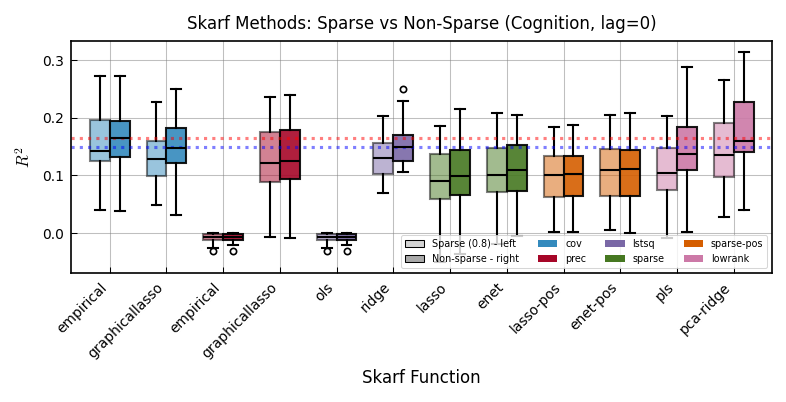

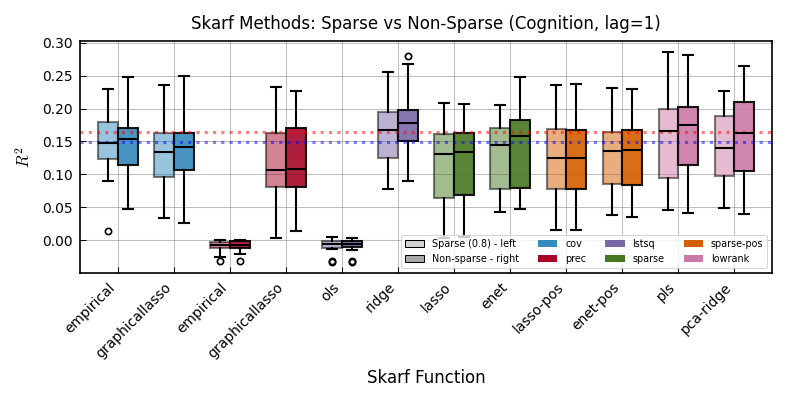

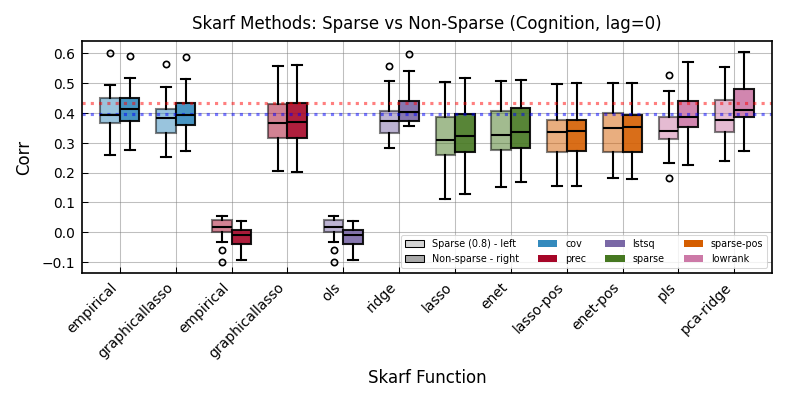

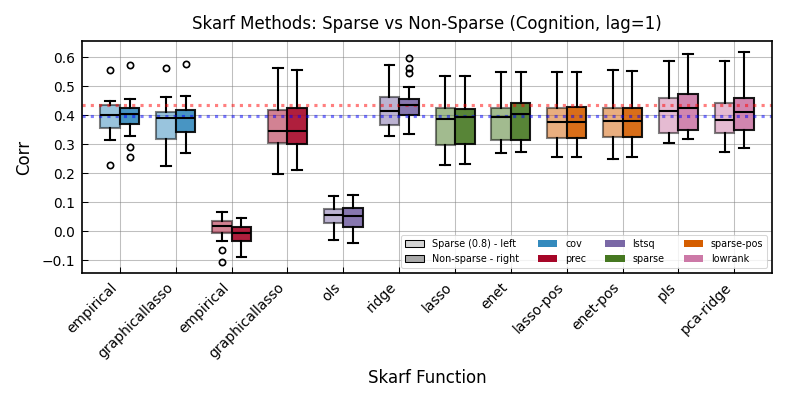

In [16]:
# Plot comparison
func_categories = {
    "cov": ["cov_empirical", "cov_graphicallasso"],
    "prec": ["prec_empirical", "prec_graphicallasso"],
    "lstsq": ["linear_ols", "linear_ridge"],
    "sparse": ["linear_lasso", "linear_enet"],
    "sparse-pos": ["linear_lasso-pos", "linear_enet-pos"],
    "lowrank": ["linear_pls", "linear_pca-ridge"],
}

func_category_map = {
    func: category for category, funcs in func_categories.items() for func in funcs
}

func_category_colors = {
    category: color_cycle[ii] for ii, category in enumerate(func_categories)
}

def plot_skarf_sparse_comparison(metric='r2', lag=0):
    f, _ = plt.subplots(1, 1, figsize=(1.5 * PLOTW, 0.75 * PLOTW), layout="constrained")
    
    funcs = AVAILABLE_SKARF_FUNCS
    n_funcs = len(funcs)
    positions = np.arange(n_funcs)
    width = 0.35
    
    sparse_data = []
    nonsparse_data = []
    colors = []
    
    for func in funcs:
        sparse_vals = skarf_comparison[
            (skarf_comparison['func'] == func) & 
            (skarf_comparison['lag'] == lag) &
            (skarf_comparison['condition'] == 'sparse (0.8)')
        ][f'{metric}_test'].values
        
        nonsparse_vals = skarf_comparison[
            (skarf_comparison['func'] == func) & 
            (skarf_comparison['lag'] == lag) &
            (skarf_comparison['condition'] == 'non-sparse')
        ][f'{metric}_test'].values
        
        sparse_data.append(sparse_vals)
        nonsparse_data.append(nonsparse_vals)
        colors.append(func_category_colors[func_category_map[func]])
    
    # Plot grouped boxplots
    bp1 = plt.boxplot(
        sparse_data,
        positions=positions - width/2,
        widths=width,
        patch_artist=True,
        medianprops={'color': 'k'},
        boxprops={'alpha': 0.5}  # Lighter for sparse
    )
    
    bp2 = plt.boxplot(
        nonsparse_data,
        positions=positions + width/2,
        widths=width,
        patch_artist=True,
        medianprops={'color': 'k'},
        boxprops={'alpha': 0.9}  # Darker for non-sparse
    )
    
    # Color the boxes - make sparse lighter, non-sparse darker
    for patch, color in zip(bp1['boxes'], colors):
        patch.set_facecolor(color)
        patch.set_alpha(0.5)  # Lighter for sparse (left)
    for patch, color in zip(bp2['boxes'], colors):
        patch.set_facecolor(color)
        patch.set_alpha(0.9)  # Darker for non-sparse (right)
    
    # Add baselines (empirical covariance)
    baseline_score_nonsparse = BASELINE_R2_NONSPARSE if metric == 'r2' else BASELINE_CORR_NONSPARSE
    baseline_score_sparse = BASELINE_R2_SPARSE if metric == 'r2' else BASELINE_CORR_SPARSE
    plt.axhline(baseline_score_nonsparse, color='r', alpha=0.5, linestyle=':', 
                label=f'Baseline non-sparse ({baseline_score_nonsparse:.3f})')
    plt.axhline(baseline_score_sparse, color='blue', alpha=0.5, linestyle=':', 
                label=f'Baseline sparse ({baseline_score_sparse:.3f})')
    
    plt.ylabel(metric_names[metric], fontsize='medium')
    plt.xlabel('Skarf Function', fontsize='medium')
    plt.xticks(positions, [f.split('_')[1] for f in funcs], rotation=45, ha='right', fontsize='small')
    
    # Legend with condition indicators and category colors
    legend_elements = [
        Patch(facecolor='lightgray', edgecolor='k', label='Sparse (0.8) - left'),
        Patch(facecolor='darkgray', edgecolor='k', label='Non-sparse - right'),
    ]
    # Add category colors
    for category, color in func_category_colors.items():
        legend_elements.append(Patch(facecolor=color, edgecolor='none', label=category))
    
    plt.legend(handles=legend_elements, loc='lower right', ncol=4, fontsize='xx-small')
    
    plt.title(f'Skarf Methods: Sparse vs Non-Sparse ({target}, lag={lag})', fontsize='medium')
    
    return f

# Plot for both lag=0 and lag=1
for metric in ['r2', 'corr']:
    for lag in [0, 1]:
        f = plot_skarf_sparse_comparison(metric, lag=lag)
        f.savefig(
            analysis_dir / f"skarf_sparse_vs_nonsparse_{target}_{metric}_lag{lag}.{FORMAT}",
            bbox_inches="tight"
        )

#### Lag=0 vs Lag=1 Comparison for Skarf Methods

Compare concurrent prediction (lag=0) vs temporal prediction (lag=1) for skarf methods under both sparse and non-sparse conditions.

In [17]:
# Statistical comparison of lag=0 vs lag=1 for skarf methods
print("="*80)
print("SKARF LAG=0 VS LAG=1 COMPARISON")
print("="*80)

# Separate by condition (sparse vs non-sparse)
for condition in ['sparse (0.8)', 'non-sparse']:
    print(f"\n{condition.upper()}:")
    print("-"*80)
    
    skarf_cond = skarf_comparison[skarf_comparison['condition'] == condition]
    
    # Get lag=0 and lag=1 data
    lag0_r2 = skarf_cond[skarf_cond['lag'] == 0]['r2_test'].values
    lag1_r2 = skarf_cond[skarf_cond['lag'] == 1]['r2_test'].values
    
    lag0_corr = skarf_cond[skarf_cond['lag'] == 0]['corr_test'].values
    lag1_corr = skarf_cond[skarf_cond['lag'] == 1]['corr_test'].values
    
    # Summary statistics
    print(f"\nLag=0: R² median={np.median(lag0_r2):.4f}, mean={np.mean(lag0_r2):.4f}, std={np.std(lag0_r2):.4f}")
    print(f"Lag=1: R² median={np.median(lag1_r2):.4f}, mean={np.mean(lag1_r2):.4f}, std={np.std(lag1_r2):.4f}")
    
    print(f"\nLag=0: Corr median={np.median(lag0_corr):.4f}, mean={np.mean(lag0_corr):.4f}, std={np.std(lag0_corr):.4f}")
    print(f"Lag=1: Corr median={np.median(lag1_corr):.4f}, mean={np.mean(lag1_corr):.4f}, std={np.std(lag1_corr):.4f}")
    
    # Statistical tests
    r2_stat, r2_pval = wilcoxon(lag0_r2, lag1_r2)
    corr_stat, corr_pval = wilcoxon(lag0_corr, lag1_corr)
    
    r2_cohens_d = compute_cohens_d(lag0_r2, lag1_r2)
    corr_cohens_d = compute_cohens_d(lag0_corr, lag1_corr)
    
    print(f"\nWilcoxon signed-rank test (lag=0 vs lag=1):")
    print(f"  R²:   stat={r2_stat:.2f}, p={r2_pval:.4g} {'*' * get_significance(r2_pval)}, Cohen's d={r2_cohens_d:.3f} ({get_effect_size_label(r2_cohens_d)})")
    print(f"  Corr: stat={corr_stat:.2f}, p={corr_pval:.4g} {'*' * get_significance(corr_pval)}, Cohen's d={corr_cohens_d:.3f} ({get_effect_size_label(corr_cohens_d)})")
    
    # Per-function comparison
    print(f"\nPer-function breakdown (R² median):")
    lag_comparison = skarf_cond.groupby(['func', 'lag'])['r2_test'].median().unstack()
    lag_comparison['diff'] = lag_comparison[0] - lag_comparison[1]
    lag_comparison = lag_comparison.sort_values('diff', ascending=False)
    print(lag_comparison.to_string())

SKARF LAG=0 VS LAG=1 COMPARISON

SPARSE (0.8):
--------------------------------------------------------------------------------

Lag=0: R² median=0.1058, mean=0.0986, std=0.0717
Lag=1: R² median=0.1205, mean=0.1121, std=0.0747

Lag=0: Corr median=0.3373, mean=0.3041, std=0.1536
Lag=1: Corr median=0.3601, mean=0.3276, std=0.1533

Wilcoxon signed-rank test (lag=0 vs lag=1):
  R²:   stat=8717.00, p=9.604e-08 ***, Cohen's d=-0.185 (negligible)
  Corr: stat=7214.00, p=1.696e-11 ***, Cohen's d=-0.153 (negligible)

Per-function breakdown (R² median):
lag                       0       1        diff
func                                           
prec_graphicallasso  0.1211  0.1073  1.3869e-02
prec_empirical      -0.0071 -0.0071 -1.6826e-05
linear_ols          -0.0071 -0.0052 -1.8989e-03
linear_pca-ridge     0.1355  0.1402 -4.6978e-03
cov_empirical        0.1422  0.1472 -5.0124e-03
cov_graphicallasso   0.1283  0.1344 -6.0641e-03
linear_lasso-pos     0.1007  0.1251 -2.4379e-02
linear_enet-pos   

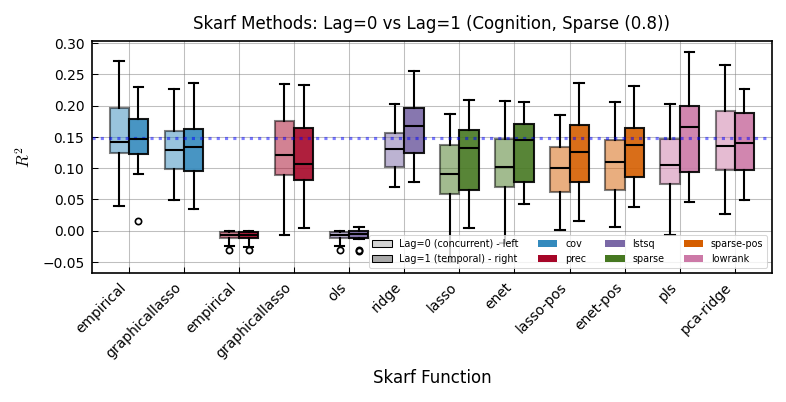

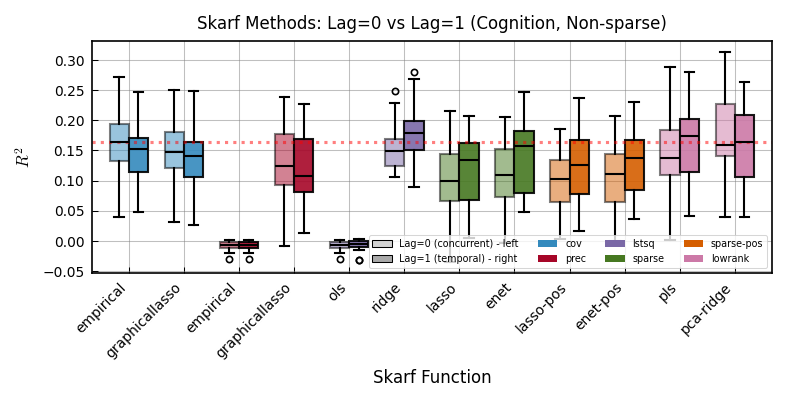

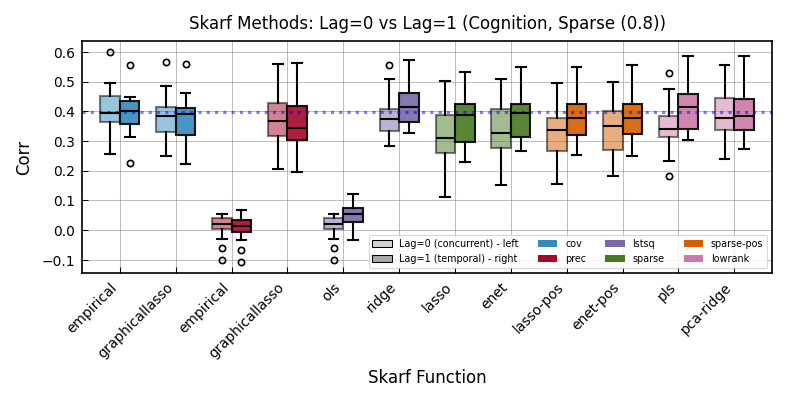

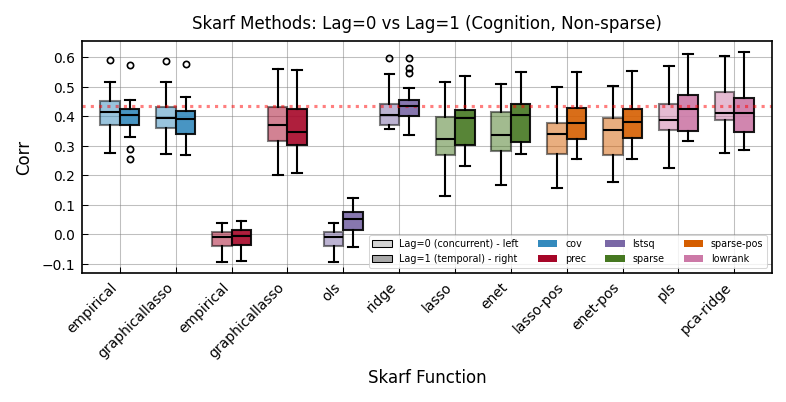

In [18]:
# Plot lag=0 vs lag=1 comparison
def plot_skarf_lag_comparison(metric='r2', condition='sparse (0.8)'):
    f, _ = plt.subplots(1, 1, figsize=(1.5 * PLOTW, 0.75 * PLOTW), layout="constrained")
    
    funcs = AVAILABLE_SKARF_FUNCS
    n_funcs = len(funcs)
    positions = np.arange(n_funcs)
    width = 0.35
    
    lag0_data = []
    lag1_data = []
    colors = []
    
    skarf_cond = skarf_comparison[skarf_comparison['condition'] == condition]
    
    for func in funcs:
        lag0_vals = skarf_cond[
            (skarf_cond['func'] == func) & 
            (skarf_cond['lag'] == 0)
        ][f'{metric}_test'].values
        
        lag1_vals = skarf_cond[
            (skarf_cond['func'] == func) & 
            (skarf_cond['lag'] == 1)
        ][f'{metric}_test'].values
        
        lag0_data.append(lag0_vals)
        lag1_data.append(lag1_vals)
        colors.append(func_category_colors[func_category_map[func]])
    
    # Plot grouped boxplots
    bp1 = plt.boxplot(
        lag0_data,
        positions=positions - width/2,
        widths=width,
        patch_artist=True,
        medianprops={'color': 'k'},
        boxprops={'alpha': 0.5}
    )
    
    bp2 = plt.boxplot(
        lag1_data,
        positions=positions + width/2,
        widths=width,
        patch_artist=True,
        medianprops={'color': 'k'},
        boxprops={'alpha': 0.9}
    )
    
    # Color the boxes
    for patch, color in zip(bp1['boxes'], colors):
        patch.set_facecolor(color)
    for patch, color in zip(bp2['boxes'], colors):
        patch.set_facecolor(color)
    
    # Add baselines (empirical covariance)
    if condition == 'sparse (0.8)':
        baseline_score = BASELINE_R2_SPARSE if metric == 'r2' else BASELINE_CORR_SPARSE
        baseline_label = f'Baseline sparse ({baseline_score:.3f})'
        baseline_color = 'blue'
    else:
        baseline_score = BASELINE_R2_NONSPARSE if metric == 'r2' else BASELINE_CORR_NONSPARSE
        baseline_label = f'Baseline non-sparse ({baseline_score:.3f})'
        baseline_color = 'r'

    plt.axhline(baseline_score, color=baseline_color, alpha=0.5, linestyle=':', label=baseline_label)

    plt.ylabel(metric_names[metric], fontsize='medium')
    plt.xlabel('Skarf Function', fontsize='medium')
    plt.xticks(positions, [f.split('_')[1] for f in funcs], rotation=45, ha='right', fontsize='small')
    
    # Legend
    legend_elements = [
        Patch(facecolor='lightgray', edgecolor='k', label='Lag=0 (concurrent) - left'),
        Patch(facecolor='darkgray', edgecolor='k', label='Lag=1 (temporal) - right'),
    ]
    # Add category colors
    for category, color in func_category_colors.items():
        legend_elements.append(Patch(facecolor=color, edgecolor='none', label=category))
    
    plt.legend(handles=legend_elements, loc='lower right', ncol=4, fontsize='xx-small')
    
    condition_label = 'Sparse (0.8)' if condition == 'sparse (0.8)' else 'Non-sparse'
    plt.title(f'Skarf Methods: Lag=0 vs Lag=1 ({target}, {condition_label})', fontsize='medium')
    
    return f

# Plot for both conditions
for metric in ['r2', 'corr']:
    for condition in ['sparse (0.8)', 'non-sparse']:
        f = plot_skarf_lag_comparison(metric, condition=condition)
        cond_suffix = 'sparse' if condition == 'sparse (0.8)' else 'nonsparse'
        f.savefig(
            analysis_dir / f"skarf_lag0_vs_lag1_{cond_suffix}_{target}_{metric}.{FORMAT}",
            bbox_inches="tight"
        )

### Part B: PySPI Methods

Compare top SPIs from each SPI family under sparse (0.8 sparsity imposed) vs non-sparse conditions. Show the top 2 performers from each SPI family to give representation across all categories.

In [19]:
# Compare PySPI sparse vs non-sparse
pyspi_sparse = sparse_results[
    (sparse_results['method'] == 'pyspi') & (sparse_results['target'] == target)
].copy()

pyspi_nonsparse = nonsparse_results[
    (nonsparse_results['method'] == 'pyspi') & (nonsparse_results['target'] == target)
].copy()

# Add condition label
pyspi_sparse['condition'] = 'sparse (0.8)'
pyspi_nonsparse['condition'] = 'non-sparse'

# Combine
pyspi_comparison = pd.concat([pyspi_sparse, pyspi_nonsparse], ignore_index=True)

# Merge with SPI metadata
pyspi_comparison = spi_table.loc[:, ["spi", "spi_id", "category", "identifier"]].merge(
    pyspi_comparison.rename(columns={'func': 'spi'}), on="spi", how="right"
)

print(f"PySPI comparison shape: {pyspi_comparison.shape}")
print(f"Number of PySPI functions: {len(pyspi_comparison['spi'].unique())}")

# Show summary statistics
pyspi_summary = pyspi_comparison.groupby('condition').agg({
    'r2_test': ['median', 'mean', 'std'],
    'corr_test': ['median', 'mean', 'std']
})
print("\nPySPI summary by condition:")
print(pyspi_summary)

PySPI comparison shape: (5920, 28)
Number of PySPI functions: 148

PySPI summary by condition:
             r2_test                 corr_test                
              median    mean     std    median    mean     std
condition                                                     
non-sparse    0.0155  0.0489  0.0750    0.1700  0.1876  0.1739
sparse (0.8)  0.0060  0.0349  0.0639    0.1415  0.1615  0.1601


In [20]:
# Create SPI category color map
spi_category_colors = {
    category: color_cycle[ii]
    for ii, category in enumerate(pyspi_comparison["category"].cat.categories)
}

print("SPI categories and colors:")
for category, color in spi_category_colors.items():
    print(f"  {category}: {color}")

SPI categories and colors:
  basic: #348ABD
  causal: #A60628
  distance: #7A68A6
  infotheory: #467821
  misc: #D55E00
  spectral: #CC79A7
  wavelet: #56B4E9


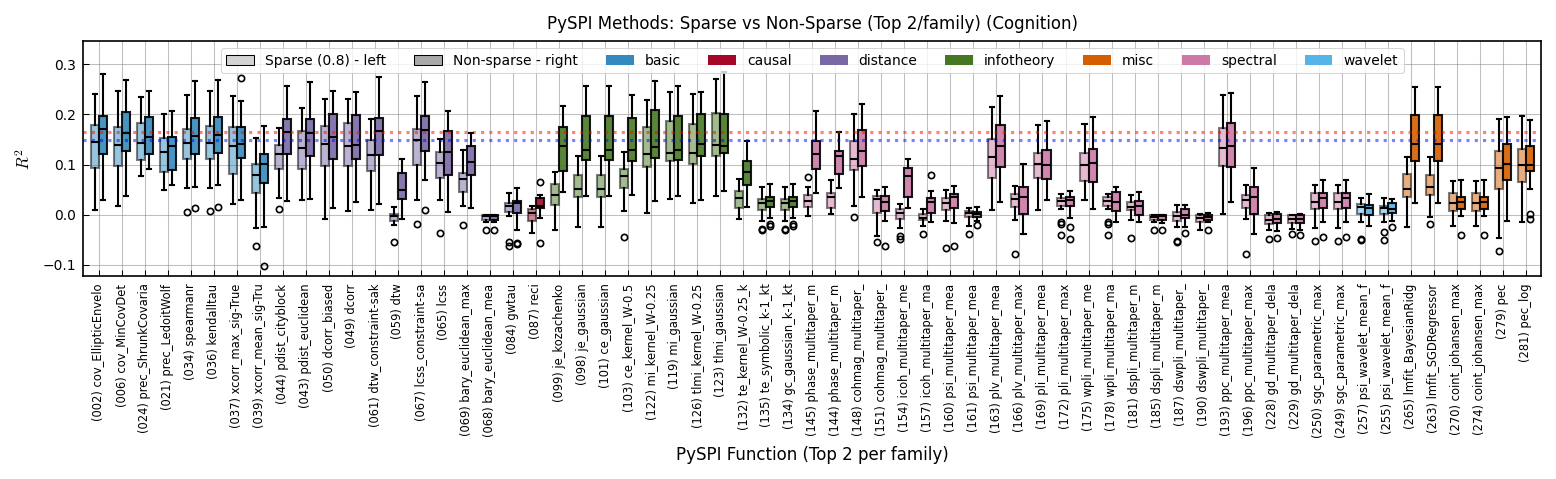

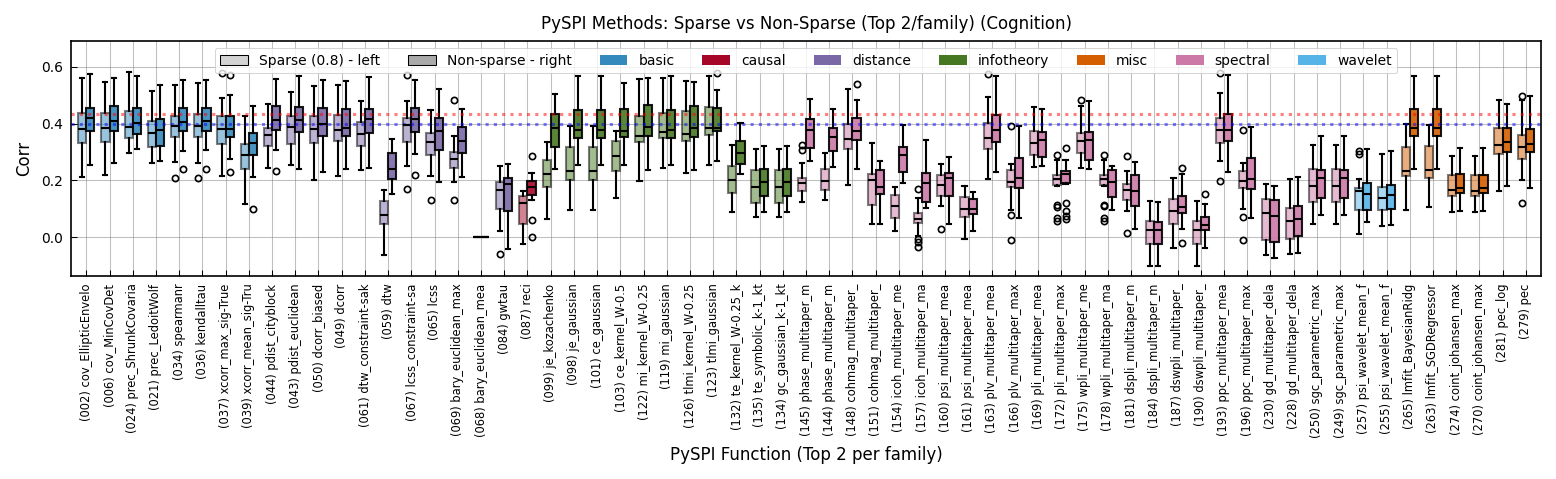

In [21]:
# Plot PySPI sparse vs non-sparse comparison by SPI family
def plot_pyspi_sparse_comparison(metric='r2', topk=2):
    f, _ = plt.subplots(1, 1, figsize=(3 * PLOTW, 0.9 * PLOTW), layout="constrained")
    
    # Get aggregated non-sparse performance by category/identifier/spi
    nonsparse_agg = pyspi_comparison[
        pyspi_comparison['condition'] == 'non-sparse'
    ].groupby(['category', 'identifier', 'spi'], observed=True)[f'{metric}_test'].median().reset_index()
    
    # Get category-identifier list in order
    cat_identifier_list = list({
        (cat, identifier): None
        for cat, identifier in zip(
            pyspi_comparison["category"], pyspi_comparison["identifier"]
        )
    })
    
    data_sparse = []
    data_nonsparse = []
    labels = []
    colors = []
    
    # Get top-k SPIs for each SPI family
    for category, identifier in cat_identifier_list:
        # Filter for this category/identifier combination
        family_data = nonsparse_agg[
            (nonsparse_agg['category'] == category) & 
            (nonsparse_agg['identifier'] == identifier)
        ].sort_values(f'{metric}_test', ascending=False).head(topk)
        
        topk_spis = family_data['spi'].tolist()
        color = spi_category_colors[category]
        
        for spi in topk_spis:
            sparse_vals = pyspi_comparison[
                (pyspi_comparison['spi'] == spi) & 
                (pyspi_comparison['condition'] == 'sparse (0.8)')
            ][f'{metric}_test'].values
            
            nonsparse_vals = pyspi_comparison[
                (pyspi_comparison['spi'] == spi) & 
                (pyspi_comparison['condition'] == 'non-sparse')
            ][f'{metric}_test'].values
            
            data_sparse.append(sparse_vals)
            data_nonsparse.append(nonsparse_vals)
            
            # Get SPI ID for labeling
            spi_id = pyspi_comparison[pyspi_comparison['spi'] == spi]['spi_id'].iloc[0]
            label = f"({spi_id + 1:03d}) {spi[:18]}"
            labels.append(label)
            colors.append(color)
    
    n_funcs = len(labels)
    positions = np.arange(n_funcs)
    width = 0.35
    
    # Plot grouped boxplots
    bp1 = plt.boxplot(
        data_sparse,
        positions=positions - width/2,
        widths=width,
        patch_artist=True,
        medianprops={'color': 'k'},
        boxprops={'alpha': 0.5}
    )
    
    bp2 = plt.boxplot(
        data_nonsparse,
        positions=positions + width/2,
        widths=width,
        patch_artist=True,
        medianprops={'color': 'k'},
        boxprops={'alpha': 0.9}
    )
    
    # Color the boxes by SPI category - make sparse lighter, non-sparse darker
    for patch, color in zip(bp1['boxes'], colors):
        patch.set_facecolor(color)
        patch.set_alpha(0.5)  # Lighter for sparse (left)
    for patch, color in zip(bp2['boxes'], colors):
        patch.set_facecolor(color)
        patch.set_alpha(0.9)  # Darker for non-sparse (right)
    
    # Add baselines
    baseline_score_nonsparse = BASELINE_R2_NONSPARSE if metric == 'r2' else BASELINE_CORR_NONSPARSE
    baseline_score_sparse = BASELINE_R2_SPARSE if metric == 'r2' else BASELINE_CORR_SPARSE
    plt.axhline(baseline_score_nonsparse, color='r', alpha=0.5, linestyle=':',
                label=f'Baseline\nnon-sparse\n({baseline_score_nonsparse:.3f})')
    plt.axhline(baseline_score_sparse, color='blue', alpha=0.5, linestyle=':',
                label=f'Baseline\nsparse\n({baseline_score_sparse:.3f})')
    
    plt.ylabel(metric_names[metric], fontsize='medium')
    plt.xlabel(f'PySPI Function (Top {topk} per family)', fontsize='medium')
    plt.xticks(positions, labels, rotation=90, fontsize='x-small')
    
    ymin, ymax = plt.ylim()
    ymax = ymin + 1.1 * (ymax - ymin)
    plt.ylim(ymin, ymax)
    
    # Legend with SPI categories and condition indicators
    legend_elements = [
        Patch(facecolor='lightgray', edgecolor='k', label='Sparse (0.8) - left'),
        Patch(facecolor='darkgray', edgecolor='k', label='Non-sparse - right'),
    ]
    # Add category colors
    for category, color in spi_category_colors.items():
        legend_elements.append(Patch(facecolor=color, edgecolor='none', label=category))
    
    plt.legend(handles=legend_elements, loc='upper center', ncol=9, fontsize='small')
    
    plt.title(f'PySPI Methods: Sparse vs Non-Sparse (Top {topk}/family) ({target})', fontsize='medium')
    
    return f

for metric in ['r2', 'corr']:
    f = plot_pyspi_sparse_comparison(metric, topk=2)
    f.savefig(
        analysis_dir / f"pyspi_sparse_vs_nonsparse_{target}_{metric}.{FORMAT}",
        bbox_inches="tight"
    )

### Detailed Performance Impact of Imposed Sparsity

In [22]:
# Filter to only identifiers with valid data
valid_identifiers = pyspi_comparison.groupby('identifier', observed=True)['r2_test'].apply(lambda x: x.notna().any())
valid_identifier_list = valid_identifiers[valid_identifiers].index.tolist()
pyspi_comparison_valid = pyspi_comparison[pyspi_comparison['identifier'].isin(valid_identifier_list)]

print(f"Total identifiers: {len(valid_identifiers)}")
print(f"Identifiers with valid data: {len(valid_identifier_list)}")
print(f"Identifiers excluded (all NaN): {(~valid_identifiers).sum()}")

# Analyze performance by SPI family (identifier) under sparse vs non-sparse conditions
pd.set_option('display.max_rows', None)  # Show all rows in output
family_comparison = pyspi_comparison_valid.groupby(['identifier', 'condition'], observed=True).agg({
    'r2_test': ['median', 'mean'],
    'corr_test': ['median', 'mean']
}).round(4).dropna()

print("\nPerformance by SPI family:")
print(family_comparison)
pd.reset_option('display.max_rows')

# Calculate performance retention (sparse / non-sparse ratio)
sparse_perf = pyspi_comparison_valid[pyspi_comparison_valid['condition'] == 'sparse (0.8)'].groupby('identifier', observed=True)['r2_test'].median()
nonsparse_perf = pyspi_comparison_valid[pyspi_comparison_valid['condition'] == 'non-sparse'].groupby('identifier', observed=True)['r2_test'].median()
retention_ratio = (sparse_perf / nonsparse_perf).sort_values(ascending=False).dropna()

print("\nPerformance retention ratio (sparse R² / non-sparse R²):")
print(retention_ratio)

# Get baseline for reference
baseline_r2 = baseline_results.loc[baseline_results["target"] == target, "r2_test"].median()
print(f"\nBaseline (non-sparse empirical cov) R²: {baseline_r2:.4f}")

Total identifiers: 33
Identifiers with valid data: 33
Identifiers excluded (all NaN): 0

Performance by SPI family:
                        r2_test         corr_test        
                         median    mean    median    mean
identifier condition                                     
bary       non-sparse    0.0067  0.0482    0.1059  0.1698
           sparse (0.8) -0.0001  0.0289    0.0657  0.1386
ce         non-sparse    0.1299  0.1478    0.3780  0.3996
           sparse (0.8)  0.0582  0.0587    0.2592  0.2651
cohmag     non-sparse    0.0026  0.0226    0.1207  0.1466
           sparse (0.8)  0.0005  0.0177    0.1011  0.1379
coint      non-sparse   -0.0025  0.0014    0.0387  0.0514
           sparse (0.8) -0.0017  0.0002    0.0436  0.0513
cov        non-sparse    0.1597  0.1525    0.4031  0.4035
           sparse (0.8)  0.1376  0.1357    0.3845  0.3833
dcorr      non-sparse    0.1445  0.1473    0.3867  0.4000
           sparse (0.8)  0.1399  0.1355    0.3803  0.3857
dspli      non

In [23]:
# Also check skarf methods performance retention (by func and lag)
skarf_sparse_perf = skarf_comparison[skarf_comparison['condition'] == 'sparse (0.8)'].groupby(['func', 'lag'])['r2_test'].median()
skarf_nonsparse_perf = skarf_comparison[skarf_comparison['condition'] == 'non-sparse'].groupby(['func', 'lag'])['r2_test'].median()
skarf_retention_ratio = (skarf_sparse_perf / skarf_nonsparse_perf).sort_values(ascending=False)

print("\nSkarf performance retention ratio (sparse R² / non-sparse R²) by function and lag:")
skarf_perf_comparison = pd.DataFrame({
    'non-sparse': skarf_nonsparse_perf,
    'sparse': skarf_sparse_perf,
    'retention_ratio': skarf_retention_ratio
}).sort_values('retention_ratio', ascending=False)
print(skarf_perf_comparison)


Skarf performance retention ratio (sparse R² / non-sparse R²) by function and lag:
                         non-sparse  sparse  retention_ratio
func                lag                                     
prec_empirical      0       -0.0062 -0.0071           1.1353
linear_ols          0       -0.0062 -0.0071           1.1353
linear_lasso-pos    1        0.1253  0.1251           0.9983
linear_enet-pos     0        0.1103  0.1098           0.9950
                    1        0.1369  0.1362           0.9947
prec_graphicallasso 1        0.1083  0.1073           0.9899
linear_lasso-pos    0        0.1023  0.1007           0.9842
linear_lasso        1        0.1344  0.1314           0.9782
prec_graphicallasso 0        0.1243  0.1211           0.9745
cov_empirical       1        0.1530  0.1472           0.9617
cov_graphicallasso  1        0.1412  0.1344           0.9512
linear_pls          1        0.1746  0.1660           0.9503
linear_ridge        1        0.1786  0.1672           0.9362
p

## Analysis 2: Compare All Methods with Natural Sparsity vs. Performance with Imposed Sparsity

In [24]:
# Get sparse results for Cognition
sparse_cognition = sparse_results[sparse_results['target'] == target].copy()

# Merge with natural sparsity info (using t=0.05 threshold)
sparse_cognition = sparse_cognition.merge(
    method_func_map[['method', 'func', 'natural_sparsity_t005']], 
    on=['method', 'func'],
    how='left'
)

# Aggregate results
sparse_agg = sparse_cognition.groupby(['method', 'func', 'natural_sparsity_t005', 'lag']).agg(
    n_splits=('split', 'count'),
    r2_test_median=('r2_test', 'median'),
    r2_test_mean=('r2_test', 'mean'),
    corr_test_median=('corr_test', 'median'),
    corr_test_mean=('corr_test', 'mean'),
).reset_index()

# Sort by r2 performance
sparse_agg = sparse_agg.sort_values('r2_test_median', ascending=False)

print(f"Number of method/func/lag combinations: {len(sparse_agg)}")
print("\nTop 20 performers:")
sparse_agg.head(20)

Number of method/func/lag combinations: 172

Top 20 performers:


,method,func,natural_sparsity_t005,lag,n_splits,r2_test_median,r2_test_mean,corr_test_median,corr_test_mean
167,skarf,linear_ridge,0.8935,1,20,0.1672,0.1656,0.4151,0.4258
165,skarf,linear_pls,0.9560,1,20,0.1660,0.1542,0.4147,0.4085
26,pyspi,cov_OAS,0.1500,0,20,0.1499,0.1437,0.3973,0.3946
22,pyspi,cov_EmpiricalCovariance,0.1445,0,20,0.1488,0.1432,0.3973,0.3939
27,pyspi,cov_ShrunkCovariance,0.1603,0,20,0.1488,0.1432,0.3973,0.3939
60,pyspi,lcss_constraint-sakoe-chiba,0.0000,0,20,0.1485,0.1339,0.3960,0.3804
24,pyspi,cov_LedoitWolf,0.1502,0,20,0.1477,0.1435,0.3965,0.3947
149,skarf,cov_empirical,0.9759,1,20,0.1472,0.1459,0.4012,0.3957
153,skarf,linear_enet,0.9269,1,20,0.1448,0.1309,0.3943,0.3827
21,pyspi,cov_EllipticEnvelope,0.1432,0,20,0.1444,0.1369,0.3814,0.3860


In [25]:
# Categorize by natural sparsity
sparse_agg['sparsity_category'] = pd.cut(
    sparse_agg['natural_sparsity_t005'],
    bins=[-0.01, 0.1, 0.5, 0.9, 1.0],
    labels=['Very sparse (0-10%)', 'Sparse (10-50%)', 'Medium (50-90%)', 'Dense (90-100%)']
)

print("\nDistribution by natural sparsity category:")
print(sparse_agg['sparsity_category'].value_counts())


Distribution by natural sparsity category:
sparsity_category
Very sparse (0-10%)    97
Sparse (10-50%)        39
Dense (90-100%)        30
Medium (50-90%)         6
Name: count, dtype: int64


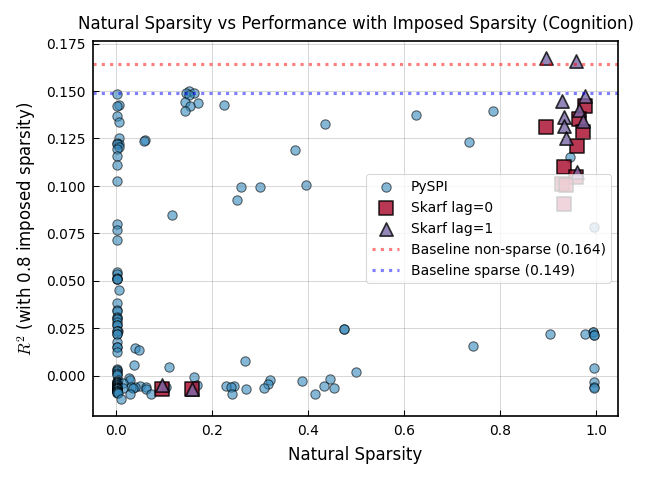

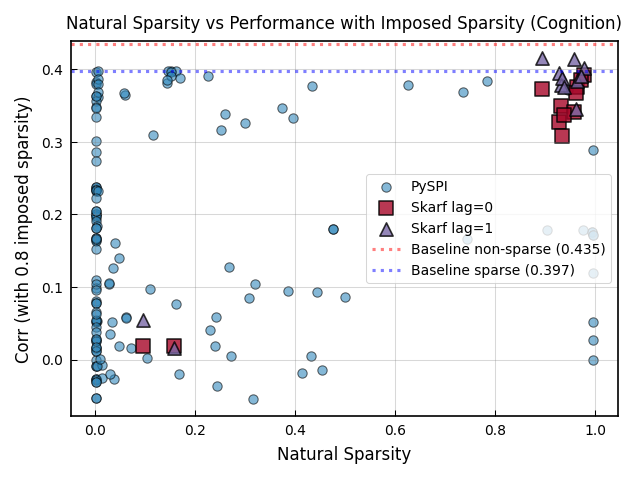

In [26]:
# Scatter plot: natural sparsity vs performance (IMPROVED)
def plot_sparsity_vs_performance(metric='r2'):
    f, ax = plt.subplots(1, 1, figsize=(1.2 * PLOTW, 0.9 * PLOTW), layout="constrained")
    
    # Separate pyspi and skarf
    pyspi_data = sparse_agg[sparse_agg['method'] == 'pyspi']
    skarf_lag0 = sparse_agg[(sparse_agg['method'] == 'skarf') & (sparse_agg['lag'] == 0)]
    skarf_lag1 = sparse_agg[(sparse_agg['method'] == 'skarf') & (sparse_agg['lag'] == 1)]
    
    # Use log scale for x-axis (most methods < 10% sparse)
    plt.scatter(
        pyspi_data['natural_sparsity_t005'] + 0.001,  # Add small offset for log
        pyspi_data[f'{metric}_test_median'],
        alpha=0.6,
        s=20,
        c=color_cycle[0],
        label='PySPI',
        edgecolors='k',
        linewidths=0.5
    )
    
    plt.scatter(
        skarf_lag0['natural_sparsity_t005'] + 0.001,
        skarf_lag0[f'{metric}_test_median'],
        alpha=0.8,
        s=40,
        c=color_cycle[1],
        marker='s',
        label='Skarf lag=0',
        edgecolors='k',
        linewidths=0.8
    )
    
    plt.scatter(
        skarf_lag1['natural_sparsity_t005'] + 0.001,
        skarf_lag1[f'{metric}_test_median'],
        alpha=0.8,
        s=40,
        c=color_cycle[2],
        marker='^',
        label='Skarf lag=1',
        edgecolors='k',
        linewidths=0.8
    )
    
    # # Annotate top performers
    # top_20 = sparse_agg.nlargest(20, f'{metric}_test_median')
    # for idx, row in top_20.iterrows():
    #     plt.annotate(
    #         row['func'][:12],
    #         xy=(row['natural_sparsity_t005'] + 0.001, row[f'{metric}_test_median']),
    #         xytext=(5, 0),
    #         textcoords='offset points',
    #         fontsize='xx-small',
    #         alpha=0.7
    #     )
    
    # Add baselines
    baseline_score_nonsparse = BASELINE_R2_NONSPARSE if metric == 'r2' else BASELINE_CORR_NONSPARSE
    baseline_score_sparse = BASELINE_R2_SPARSE if metric == 'r2' else BASELINE_CORR_SPARSE
    plt.axhline(baseline_score_nonsparse, color='r', alpha=0.5, linestyle=':', 
                label=f'Baseline non-sparse ({baseline_score_nonsparse:.3f})')
    plt.axhline(baseline_score_sparse, color='blue', alpha=0.5, linestyle=':', 
                label=f'Baseline sparse ({baseline_score_sparse:.3f})')

    plt.xlabel('Natural Sparsity', fontsize='medium')
    plt.ylabel(f'{metric_names[metric]} (with 0.8 imposed sparsity)', fontsize='medium')
    plt.title(f'Natural Sparsity vs Performance with Imposed Sparsity ({target})', fontsize='medium')
    plt.legend(loc='center right', fontsize='small')
    plt.grid(True, alpha=0.3, which='both')
    
    return f

for metric in ['r2', 'corr']:
    f = plot_sparsity_vs_performance(metric)
    f.savefig(
        analysis_dir / f"natural_sparsity_vs_performance_{target}_{metric}.{FORMAT}",
        bbox_inches="tight"
    )

In [27]:
# Print actual values for Analysis 2: Natural sparsity vs performance
print("\n" + "="*80)
print("ANALYSIS 2: NATURAL SPARSITY VS PERFORMANCE WITH IMPOSED SPARSITY")
print("="*80)

print("\nTop 10 methods by R² with imposed 0.8 sparsity:")
top_10 = sparse_agg[['method', 'func', 'natural_sparsity_t005', 'r2_test_median', 'corr_test_median']].head(10)
for idx, row in top_10.iterrows():
    print(f"  {row['method']:6s} {row['func'][:30]:30s} nat_spar={row['natural_sparsity_t005']:.4f} R²={row['r2_test_median']:.4f} corr={row['corr_test_median']:.4f}")

print("\n\nSkarf methods (all 12) sorted by R² performance:")
skarf_perf = sparse_agg[sparse_agg['method'] == 'skarf'][['func', 'natural_sparsity_t005', 'r2_test_median', 'corr_test_median']].sort_values('r2_test_median', ascending=False)
for idx, row in skarf_perf.iterrows():
    print(f"  {row['func']:25s} nat_spar={row['natural_sparsity_t005']:.4f} R²={row['r2_test_median']:.4f} corr={row['corr_test_median']:.4f}")

print("\n\nPySPI top 10 by R² with imposed sparsity:")
pyspi_top = sparse_agg[sparse_agg['method'] == 'pyspi'][['func', 'natural_sparsity_t005', 'r2_test_median', 'corr_test_median']].head(10)
for idx, row in pyspi_top.iterrows():
    print(f"  {row['func'][:35]:35s} nat_spar={row['natural_sparsity_t005']:.4f} R²={row['r2_test_median']:.4f} corr={row['corr_test_median']:.4f}")

print("\n\nSummary statistics by method:")
summary_by_method = sparse_agg.groupby('method').agg({
    'r2_test_median': ['mean', 'median', 'std', 'min', 'max'],
    'natural_sparsity_t005': ['mean', 'median']
}).round(4)
print(summary_by_method)


ANALYSIS 2: NATURAL SPARSITY VS PERFORMANCE WITH IMPOSED SPARSITY

Top 10 methods by R² with imposed 0.8 sparsity:
  skarf  linear_ridge                   nat_spar=0.8935 R²=0.1672 corr=0.4151
  skarf  linear_pls                     nat_spar=0.9560 R²=0.1660 corr=0.4147
  pyspi  cov_OAS                        nat_spar=0.1500 R²=0.1499 corr=0.3973
  pyspi  cov_EmpiricalCovariance        nat_spar=0.1445 R²=0.1488 corr=0.3973
  pyspi  cov_ShrunkCovariance           nat_spar=0.1603 R²=0.1488 corr=0.3973
  pyspi  lcss_constraint-sakoe-chiba    nat_spar=0.0000 R²=0.1485 corr=0.3960
  pyspi  cov_LedoitWolf                 nat_spar=0.1502 R²=0.1477 corr=0.3965
  skarf  cov_empirical                  nat_spar=0.9759 R²=0.1472 corr=0.4012
  skarf  linear_enet                    nat_spar=0.9269 R²=0.1448 corr=0.3943
  pyspi  cov_EllipticEnvelope           nat_spar=0.1432 R²=0.1444 corr=0.3814


Skarf methods (all 12) sorted by R² performance:
  linear_ridge              nat_spar=0.8935 R²=0.1672

## Analysis 3: Top Performers with Imposed Sparsity

In [28]:
# Get top 20 methods by median r2
top_k = 20
top_methods = sparse_agg.nlargest(top_k, 'r2_test_median')[['method', 'func', 'lag']]

# Get full distributions for top methods
top_sparse_results = sparse_cognition.merge(
    top_methods,
    on=['method', 'func', 'lag'],
    how='inner'
)

print(f"Top {top_k} methods by R² performance:")
for idx, row in top_methods.iterrows():
    lag_str = f" lag={int(row['lag'])}" if row['method'] == 'skarf' else ""
    print(f"  {row['method']:6s} - {row['func']}{lag_str}")

Top 20 methods by R² performance:
  skarf  - linear_ridge lag=1
  skarf  - linear_pls lag=1
  pyspi  - cov_OAS
  pyspi  - cov_EmpiricalCovariance
  pyspi  - cov_ShrunkCovariance
  pyspi  - lcss_constraint-sakoe-chiba
  pyspi  - cov_LedoitWolf
  skarf  - cov_empirical lag=1
  skarf  - linear_enet lag=1
  pyspi  - cov_EllipticEnvelope
  pyspi  - prec_ShrunkCovariance
  pyspi  - pdist_canberra
  pyspi  - kendalltau
  skarf  - cov_empirical lag=0
  pyspi  - spearmanr
  pyspi  - dcorr_biased
  skarf  - linear_pca-ridge lag=1
  pyspi  - tlmi_gaussian
  pyspi  - cov_MinCovDet
  pyspi  - dcorr


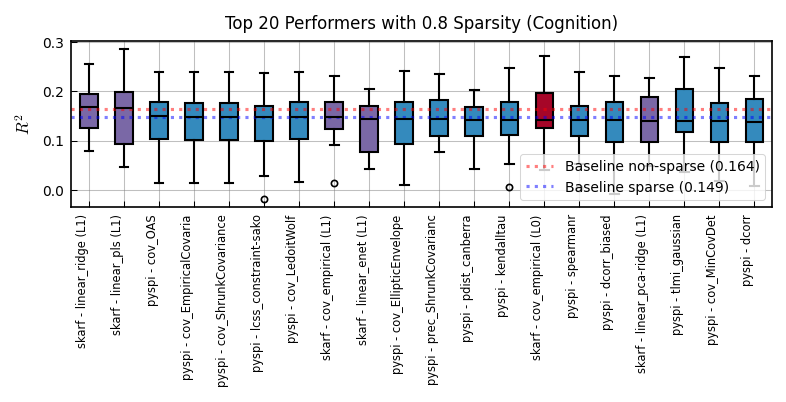

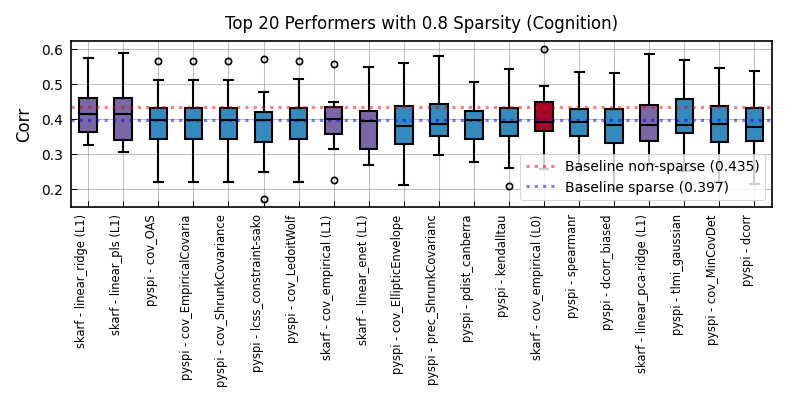

In [29]:
# Plot top performers
def plot_top_performers(metric='r2'):
    f, ax = plt.subplots(1, 1, figsize=(1.5 * PLOTW, 0.75 * PLOTW), layout="constrained")
    
    data = []
    labels = []
    colors = []
    
    for idx, row in top_methods.iterrows():
        method = row['method']
        func = row['func']
        lag = row['lag']
        
        values = top_sparse_results[
            (top_sparse_results['method'] == method) &
            (top_sparse_results['func'] == func) &
            (top_sparse_results['lag'] == lag)
        ][f'{metric}_test'].values
        
        data.append(values)
        
        # Create label with lag info for skarf methods
        if method == 'skarf':
            labels.append(f"{method} - {func[:20]} (L{int(lag)})")
        else:
            labels.append(f"{method} - {func[:20]}")
        
        # Use different colors for skarf lag=0 vs lag=1
        if method == 'pyspi':
            colors.append(color_cycle[0])
        elif lag == 0:
            colors.append(color_cycle[1])
        else:  # lag == 1
            colors.append(color_cycle[2])
    
    pos = np.arange(len(data))
    bplot = plt.boxplot(
        data,
        positions=pos,
        patch_artist=True,
        medianprops={'color': 'k'}
    )
    
    for patch, color in zip(bplot['boxes'], colors):
        patch.set_facecolor(color)
    
    # Add baselines
    baseline_score_nonsparse = BASELINE_R2_NONSPARSE if metric == 'r2' else BASELINE_CORR_NONSPARSE
    baseline_score_sparse = BASELINE_R2_SPARSE if metric == 'r2' else BASELINE_CORR_SPARSE
    plt.axhline(baseline_score_nonsparse, color='r', alpha=0.5, linestyle=':', 
                label=f'Baseline non-sparse ({baseline_score_nonsparse:.3f})')
    plt.axhline(baseline_score_sparse, color='blue', alpha=0.5, linestyle=':', 
                label=f'Baseline sparse ({baseline_score_sparse:.3f})')
    
    plt.ylabel(metric_names[metric], fontsize='medium')
    plt.xticks(pos, labels, rotation=90, fontsize='x-small', ha='right')
    plt.title(f'Top {top_k} Performers with 0.8 Sparsity ({target})', fontsize='medium')
    plt.legend(loc='lower right', fontsize='small')
    
    return f

for metric in ['r2', 'corr']:
    f = plot_top_performers(metric)
    f.savefig(
        analysis_dir / f"top_performers_sparse_{target}_{metric}.{FORMAT}",
        bbox_inches="tight"
    )

In [30]:
# Print actual values for Analysis 3: Top performers
print("\n" + "="*80)
print("ANALYSIS 3: TOP 20 PERFORMERS WITH IMPOSED 0.8 SPARSITY")
print("="*80)

top_20_detailed = sparse_agg.nlargest(20, 'r2_test_median')[
    ['method', 'func', 'lag', 'natural_sparsity_t005', 'r2_test_median', 'r2_test_mean', 'corr_test_median', 'corr_test_mean']
].reset_index(drop=True)

print("\nTop 20 methods:")
for idx, row in top_20_detailed.iterrows():
    lag_str = f" lag={int(row['lag'])}" if row['method'] == 'skarf' else ""
    print(f"{idx+1:2d}. {row['method']:6s} {row['func'][:25]:25s}{lag_str:8s} nat_spar={row['natural_sparsity_t005']:.4f} R²={row['r2_test_median']:.4f} corr={row['corr_test_median']:.4f}")

print("\n\nBreakdown by method type in top 20:")
top_20_counts = top_20_detailed['method'].value_counts()
print(f"  Skarf: {top_20_counts.get('skarf', 0)}")
print(f"  PySPI: {top_20_counts.get('pyspi', 0)}")

print("\n\nSkarf methods in top 20 (ranked by position):")
top_20_skarf = top_20_detailed[top_20_detailed['method'] == 'skarf'].reset_index(drop=True)
for idx, row in top_20_skarf.iterrows():
    orig_rank = top_20_detailed[(top_20_detailed['func'] == row['func']) & (top_20_detailed.get('lag', 0) == row.get('lag', 0))].index[0] + 1
    lag_str = f" lag={int(row['lag'])}" if 'lag' in row else ""
    print(f"  Rank {orig_rank:2d}: {row['func']:25s}{lag_str:8s} R²={row['r2_test_median']:.4f} corr={row['corr_test_median']:.4f}")

print("\n\nPySPI methods in top 20 (ranked by position):")
top_20_pyspi = top_20_detailed[top_20_detailed['method'] == 'pyspi'].reset_index(drop=True)
for idx, row in top_20_pyspi.iterrows():
    orig_rank = top_20_detailed[top_20_detailed['func'] == row['func']].index[0] + 1
    print(f"  Rank {orig_rank:2d}: {row['func'][:35]:35s} R²={row['r2_test_median']:.4f} corr={row['corr_test_median']:.4f}")


ANALYSIS 3: TOP 20 PERFORMERS WITH IMPOSED 0.8 SPARSITY

Top 20 methods:
 1. skarf  linear_ridge              lag=1   nat_spar=0.8935 R²=0.1672 corr=0.4151
 2. skarf  linear_pls                lag=1   nat_spar=0.9560 R²=0.1660 corr=0.4147
 3. pyspi  cov_OAS                           nat_spar=0.1500 R²=0.1499 corr=0.3973
 4. pyspi  cov_EmpiricalCovariance           nat_spar=0.1445 R²=0.1488 corr=0.3973
 5. pyspi  cov_ShrunkCovariance              nat_spar=0.1603 R²=0.1488 corr=0.3973
 6. pyspi  lcss_constraint-sakoe-chi         nat_spar=0.0000 R²=0.1485 corr=0.3960
 7. pyspi  cov_LedoitWolf                    nat_spar=0.1502 R²=0.1477 corr=0.3965
 8. skarf  cov_empirical             lag=1   nat_spar=0.9759 R²=0.1472 corr=0.4012
 9. skarf  linear_enet               lag=1   nat_spar=0.9269 R²=0.1448 corr=0.3943
10. pyspi  cov_EllipticEnvelope              nat_spar=0.1432 R²=0.1444 corr=0.3814
11. pyspi  prec_ShrunkCovariance             nat_spar=0.1689 R²=0.1437 corr=0.3874
12. pyspi  pd

## Analysis 4: Distributions and Statistical Testing

In [31]:
# Get distributions for pyspi vs skarf with imposed sparsity
pyspi_sparse_r2 = sparse_cognition[sparse_cognition['method'] == 'pyspi']['r2_test'].values
skarf_sparse_r2 = sparse_cognition[sparse_cognition['method'] == 'skarf']['r2_test'].values
skarf_lag0_r2 = sparse_cognition[(sparse_cognition['method'] == 'skarf') & (sparse_cognition['lag'] == 0)]['r2_test'].values
skarf_lag1_r2 = sparse_cognition[(sparse_cognition['method'] == 'skarf') & (sparse_cognition['lag'] == 1)]['r2_test'].values

pyspi_sparse_corr = sparse_cognition[sparse_cognition['method'] == 'pyspi']['corr_test'].values
skarf_sparse_corr = sparse_cognition[sparse_cognition['method'] == 'skarf']['corr_test'].values
skarf_lag0_corr = sparse_cognition[(sparse_cognition['method'] == 'skarf') & (sparse_cognition['lag'] == 0)]['corr_test'].values
skarf_lag1_corr = sparse_cognition[(sparse_cognition['method'] == 'skarf') & (sparse_cognition['lag'] == 1)]['corr_test'].values

print("="*80)
print("STATISTICAL TESTING: Skarf vs PySPI with Imposed 0.8 Sparsity")
print("="*80)
print("\nNOTE: This test pools all methods from each family, which may obscure")
print("meaningful subgroup differences. See Analysis 5 for stratified tests.")

# Test 1: Skarf (both lags) vs PySPI
r2_stat, r2_pval = mannwhitneyu(skarf_sparse_r2, pyspi_sparse_r2)
corr_stat, corr_pval = mannwhitneyu(skarf_sparse_corr, pyspi_sparse_corr)
r2_cohens_d = compute_cohens_d(skarf_sparse_r2, pyspi_sparse_r2)
corr_cohens_d = compute_cohens_d(skarf_sparse_corr, pyspi_sparse_corr)

print("\n1. Mann-Whitney U test (Skarf both lags vs PySPI):")
print(f"\nR² test:")
print(f"  Skarf median: {np.median(skarf_sparse_r2):.4f}")
print(f"  PySPI median: {np.median(pyspi_sparse_r2):.4f}")
print(f"  U statistic: {r2_stat:.2f}")
print(f"  p-value: {r2_pval:.4e} {get_significance(r2_pval) * '*'}")
print(f"  Cohen's d: {r2_cohens_d:.4f} ({get_effect_size_label(r2_cohens_d)})")

# Test 2: Skarf lag=0 vs PySPI
r2_stat_lag0, r2_pval_lag0 = mannwhitneyu(skarf_lag0_r2, pyspi_sparse_r2)
r2_cohens_d_lag0 = compute_cohens_d(skarf_lag0_r2, pyspi_sparse_r2)

print("\n2. Mann-Whitney U test (Skarf lag=0 vs PySPI):")
print(f"\nR² test:")
print(f"  Skarf lag=0 median: {np.median(skarf_lag0_r2):.4f}")
print(f"  PySPI median: {np.median(pyspi_sparse_r2):.4f}")
print(f"  U statistic: {r2_stat_lag0:.2f}")
print(f"  p-value: {r2_pval_lag0:.4e} {get_significance(r2_pval_lag0) * '*'}")
print(f"  Cohen's d: {r2_cohens_d_lag0:.4f} ({get_effect_size_label(r2_cohens_d_lag0)})")

# Test 3: Skarf lag=1 vs PySPI
r2_stat_lag1, r2_pval_lag1 = mannwhitneyu(skarf_lag1_r2, pyspi_sparse_r2)
r2_cohens_d_lag1 = compute_cohens_d(skarf_lag1_r2, pyspi_sparse_r2)

print("\n3. Mann-Whitney U test (Skarf lag=1 vs PySPI):")
print(f"\nR² test:")
print(f"  Skarf lag=1 median: {np.median(skarf_lag1_r2):.4f}")
print(f"  PySPI median: {np.median(pyspi_sparse_r2):.4f}")
print(f"  U statistic: {r2_stat_lag1:.2f}")
print(f"  p-value: {r2_pval_lag1:.4e} {get_significance(r2_pval_lag1) * '*'}")
print(f"  Cohen's d: {r2_cohens_d_lag1:.4f} ({get_effect_size_label(r2_cohens_d_lag1)})")

print(f"\nCorrelation test:")
print(f"  Skarf median: {np.median(skarf_sparse_corr):.4f}")
print(f"  PySPI median: {np.median(pyspi_sparse_corr):.4f}")
print(f"  U statistic: {corr_stat:.2f}")
print(f"  p-value: {corr_pval:.4e} {get_significance(corr_pval) * '*'}")
print(f"  Cohen's d: {corr_cohens_d:.4f} ({get_effect_size_label(corr_cohens_d)})")
print("="*80)

STATISTICAL TESTING: Skarf vs PySPI with Imposed 0.8 Sparsity

NOTE: This test pools all methods from each family, which may obscure
meaningful subgroup differences. See Analysis 5 for stratified tests.

1. Mann-Whitney U test (Skarf both lags vs PySPI):

R² test:
  Skarf median: 0.1111
  PySPI median: 0.0060
  U statistic: 1075000.00
  p-value: 6.1966e-73 ***
  Cohen's d: 1.0787 (large)

2. Mann-Whitney U test (Skarf lag=0 vs PySPI):

R² test:
  Skarf lag=0 median: 0.1058
  PySPI median: 0.0060
  U statistic: 525167.00
  p-value: 5.0594e-35 ***
  Cohen's d: 0.9874 (large)

3. Mann-Whitney U test (Skarf lag=1 vs PySPI):

R² test:
  Skarf lag=1 median: 0.1205
  PySPI median: 0.0060
  U statistic: 549833.00
  p-value: 2.1908e-45 ***
  Cohen's d: 1.1924 (large)

Correlation test:
  Skarf median: 0.3471
  PySPI median: 0.1415
  U statistic: 1073563.00
  p-value: 2.2451e-72 ***
  Cohen's d: 0.9692 (large)


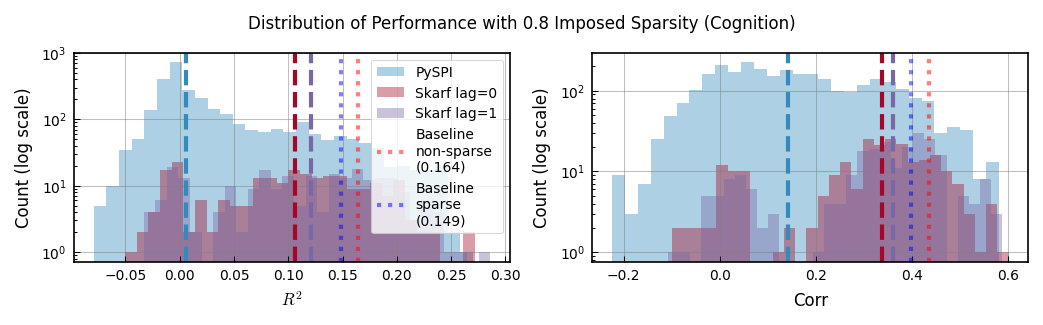

In [32]:
# Visualize distributions
f, axs = plt.subplots(1, 2, figsize=(2 * PLOTW, 0.6 * PLOTW), layout="constrained")

for idx, metric in enumerate(['r2', 'corr']):
    ax = axs[idx]
    plt.sca(ax)
    
    pyspi_vals = sparse_cognition[sparse_cognition['method'] == 'pyspi'][f'{metric}_test'].values
    skarf_lag0_vals = sparse_cognition[(sparse_cognition['method'] == 'skarf') & (sparse_cognition['lag'] == 0)][f'{metric}_test'].values
    skarf_lag1_vals = sparse_cognition[(sparse_cognition['method'] == 'skarf') & (sparse_cognition['lag'] == 1)][f'{metric}_test'].values
    
    plt.hist(pyspi_vals, bins=30, alpha=0.4, label='PySPI', color=color_cycle[0])
    plt.hist(skarf_lag0_vals, bins=30, alpha=0.4, label='Skarf lag=0', color=color_cycle[1])
    plt.hist(skarf_lag1_vals, bins=30, alpha=0.4, label='Skarf lag=1', color=color_cycle[2])
    
    plt.axvline(np.median(pyspi_vals), color=color_cycle[0], linestyle='--', linewidth=2)
    plt.axvline(np.median(skarf_lag0_vals), color=color_cycle[1], linestyle='--', linewidth=2)
    plt.axvline(np.median(skarf_lag1_vals), color=color_cycle[2], linestyle='--', linewidth=2)
    
    # Add baselines
    baseline_score_nonsparse = BASELINE_R2_NONSPARSE if metric == 'r2' else BASELINE_CORR_NONSPARSE
    baseline_score_sparse = BASELINE_R2_SPARSE if metric == 'r2' else BASELINE_CORR_SPARSE
    plt.axvline(baseline_score_nonsparse, color='r', alpha=0.5, linestyle=':', linewidth=2, 
                label=f'Baseline\nnon-sparse\n({baseline_score_nonsparse:.3f})')
    plt.axvline(baseline_score_sparse, color='blue', alpha=0.5, linestyle=':', linewidth=2, 
                label=f'Baseline\nsparse\n({baseline_score_sparse:.3f})')
    
    plt.xlabel(metric_names[metric], fontsize='medium')
    plt.ylabel('Count (log scale)', fontsize='medium')
    
    plt.yscale('log')
    
    if idx == 0:
        plt.legend(loc='upper right', fontsize='small')

f.suptitle(f'Distribution of Performance with 0.8 Imposed Sparsity ({target})', fontsize='medium')

f.savefig(
    analysis_dir / f"pyspi_vs_skarf_distributions_sparse_{target}.{FORMAT}",
    bbox_inches="tight"
)

## Analysis 5: Stratified Comparison by Natural Sparsity

Test whether methods with similar natural sparsity perform similarly under imposed sparsity, regardless of method family (PySPI vs skarf).

In [33]:
# Define sparsity bins
sparsity_bins = [0, 0.25, 0.50, 0.75, 1.0]
sparsity_labels = ['0-25%', '25-50%', '50-75%', '75-100%']

sparse_cognition['sparsity_bin'] = pd.cut(
    sparse_cognition['natural_sparsity_t005'], 
    bins=sparsity_bins, 
    labels=sparsity_labels,
    include_lowest=True
)

# Test within each bin
print("="*80)
print("STRATIFIED COMPARISON: PySPI vs Skarf by Natural Sparsity Bins")
print("="*80)

for bin_label in sparsity_labels:
    bin_data = sparse_cognition[sparse_cognition['sparsity_bin'] == bin_label]
    
    pyspi_data = bin_data[bin_data['method'] == 'pyspi']['r2_test'].values
    skarf_data = bin_data[bin_data['method'] == 'skarf']['r2_test'].values
    
    if len(pyspi_data) > 0 and len(skarf_data) > 0:
        stat, pval = mannwhitneyu(skarf_data, pyspi_data, alternative='two-sided')
        
        print(f"\n{bin_label} Natural Sparsity:")
        print(f"  PySPI: n={len(pyspi_data)//20:3d} methods, median R²={np.median(pyspi_data):.4f}")
        print(f"  Skarf: n={len(skarf_data)//20:3d} methods, median R²={np.median(skarf_data):.4f}")
        print(f"  Mann-Whitney U: p={pval:.4e} {get_significance(pval) * '*'}")
    else:
        print(f"\n{bin_label} Natural Sparsity: Insufficient data")
        print(f"  PySPI: n={len(pyspi_data)//20 if len(pyspi_data) > 0 else 0}")
        print(f"  Skarf: n={len(skarf_data)//20 if len(skarf_data) > 0 else 0}")

STRATIFIED COMPARISON: PySPI vs Skarf by Natural Sparsity Bins

0-25% Natural Sparsity:
  PySPI: n=113 methods, median R²=0.0041
  Skarf: n=  4 methods, median R²=-0.0064
  Mann-Whitney U: p=3.9340e-12 ***

25-50% Natural Sparsity: Insufficient data
  PySPI: n=19
  Skarf: n=0

50-75% Natural Sparsity: Insufficient data
  PySPI: n=3
  Skarf: n=0

75-100% Natural Sparsity:
  PySPI: n= 13 methods, median R²=0.0179
  Skarf: n= 20 methods, median R²=0.1278
  Mann-Whitney U: p=7.0618e-59 ***


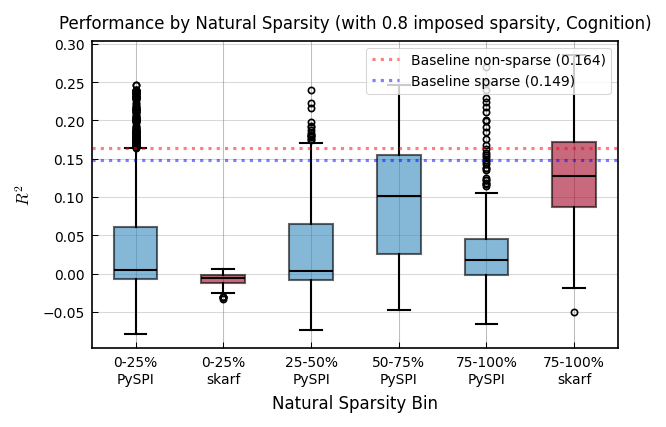

In [34]:
# Visualize stratified comparison
f, ax = plt.subplots(1, 1, figsize=(1.2 * PLOTW, 0.8 * PLOTW), layout="constrained")

# Prepare data for boxplot
plot_data = []
plot_labels = []
plot_colors = []

for bin_label in sparsity_labels:
    bin_data = sparse_cognition[sparse_cognition['sparsity_bin'] == bin_label]
    
    pyspi_vals = bin_data[bin_data['method'] == 'pyspi']['r2_test'].values
    skarf_vals = bin_data[bin_data['method'] == 'skarf']['r2_test'].values
    
    if len(pyspi_vals) > 0:
        plot_data.append(pyspi_vals)
        plot_labels.append(f"{bin_label}\nPySPI")
        plot_colors.append(color_cycle[0])
    
    if len(skarf_vals) > 0:
        plot_data.append(skarf_vals)
        plot_labels.append(f"{bin_label}\nskarf")
        plot_colors.append(color_cycle[1])

bp = plt.boxplot(plot_data, tick_labels=plot_labels, patch_artist=True, medianprops={'color': 'k'})

for patch, color in zip(bp['boxes'], plot_colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.6)

# Add baselines
plt.axhline(BASELINE_R2_NONSPARSE, color='r', alpha=0.5, linestyle=':', 
            label=f'Baseline non-sparse ({BASELINE_R2_NONSPARSE:.3f})')
plt.axhline(BASELINE_R2_SPARSE, color='blue', alpha=0.5, linestyle=':', 
            label=f'Baseline sparse ({BASELINE_R2_SPARSE:.3f})')

plt.ylabel('$R^2$', fontsize='medium')
plt.xlabel('Natural Sparsity Bin', fontsize='medium')
plt.title(f'Performance by Natural Sparsity (with 0.8 imposed sparsity, {target})', fontsize='medium')
plt.xticks(rotation=0, fontsize='small')
plt.legend(loc='upper right', fontsize='small')
plt.grid(axis='y', alpha=0.3)

f.savefig(analysis_dir / f"stratified_comparison_r2_{target}.{FORMAT}", bbox_inches="tight")

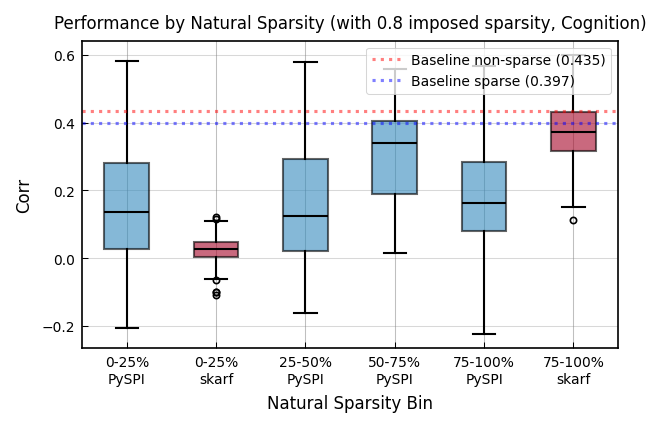

In [35]:
# Visualize stratified comparison for correlation
f, ax = plt.subplots(1, 1, figsize=(1.2 * PLOTW, 0.8 * PLOTW), layout="constrained")

# Prepare data for boxplot
plot_data = []
plot_labels = []
plot_colors = []

for bin_label in sparsity_labels:
    bin_data = sparse_cognition[sparse_cognition['sparsity_bin'] == bin_label]
    
    pyspi_vals = bin_data[bin_data['method'] == 'pyspi']['corr_test'].values
    skarf_vals = bin_data[bin_data['method'] == 'skarf']['corr_test'].values
    
    if len(pyspi_vals) > 0:
        plot_data.append(pyspi_vals)
        plot_labels.append(f"{bin_label}\nPySPI")
        plot_colors.append(color_cycle[0])
    
    if len(skarf_vals) > 0:
        plot_data.append(skarf_vals)
        plot_labels.append(f"{bin_label}\nskarf")
        plot_colors.append(color_cycle[1])

bp = plt.boxplot(plot_data, tick_labels=plot_labels, patch_artist=True, medianprops={'color': 'k'})

for patch, color in zip(bp['boxes'], plot_colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.6)

# Add baselines
plt.axhline(BASELINE_CORR_NONSPARSE, color='r', alpha=0.5, linestyle=':', 
            label=f'Baseline non-sparse ({BASELINE_CORR_NONSPARSE:.3f})')
plt.axhline(BASELINE_CORR_SPARSE, color='blue', alpha=0.5, linestyle=':', 
            label=f'Baseline sparse ({BASELINE_CORR_SPARSE:.3f})')

plt.ylabel('Corr', fontsize='medium')
plt.xlabel('Natural Sparsity Bin', fontsize='medium')
plt.title(f'Performance by Natural Sparsity (with 0.8 imposed sparsity, {target})', fontsize='medium')
plt.xticks(rotation=0, fontsize='small')
plt.legend(loc='upper right', fontsize='small')
plt.grid(axis='y', alpha=0.3)

f.savefig(analysis_dir / f"stratified_comparison_corr_{target}.{FORMAT}", bbox_inches="tight")

## Analysis 6: Rank Correlation Analysis

In [36]:
# Get non-sparse aggregated performance (including lag for skarf)
nonsparse_cognition = nonsparse_results[nonsparse_results['target'] == target].copy()
nonsparse_agg = nonsparse_cognition.groupby(['method', 'func', 'lag']).agg(
    r2_test_median=('r2_test', 'median'),
    corr_test_median=('corr_test', 'median'),
).reset_index()

# Merge sparse and non-sparse (matching on method, func, and lag)
rank_comparison = sparse_agg[['method', 'func', 'lag', 'r2_test_median', 'corr_test_median']].merge(
    nonsparse_agg[['method', 'func', 'lag', 'r2_test_median', 'corr_test_median']],
    on=['method', 'func', 'lag'],
    suffixes=('_sparse', '_nonsparse'),
    how='inner'
)

# Calculate ranks
rank_comparison['rank_sparse'] = rank_comparison['r2_test_median_sparse'].rank(ascending=False)
rank_comparison['rank_nonsparse'] = rank_comparison['r2_test_median_nonsparse'].rank(ascending=False)
rank_comparison['rank_change'] = rank_comparison['rank_nonsparse'] - rank_comparison['rank_sparse']

# Spearman correlation
rho, pval = spearmanr(rank_comparison['r2_test_median_nonsparse'], rank_comparison['r2_test_median_sparse'])

print(f"Rank correlation between non-sparse and sparse performance:")
print(f"  Spearman's ρ = {rho:.4f}, p = {pval:.4e} {get_significance(pval) * '*'}")
print(f"\nTop 10 biggest rank improvements (non-sparse → sparse):")
rank_comparison.nsmallest(10, 'rank_change')[['method', 'func', 'rank_nonsparse', 'rank_sparse', 'rank_change']].round(0)

Rank correlation between non-sparse and sparse performance:
  Spearman's ρ = 0.9346, p = 3.0893e-78 ***

Top 10 biggest rank improvements (non-sparse → sparse):


,method,func,rank_nonsparse,rank_sparse,rank_change
162,pyspi,plv_multitaper_max_fs-1_fmin-0_fmax-0-5,103.0,163.0,-60.0
160,pyspi,ppc_multitaper_max_fs-1_fmin-0_fmax-0-5,104.0,161.0,-57.0
142,pyspi,icoh_multitaper_max_fs-1_fmin-0_fmax-0-25,88.0,143.0,-55.0
132,pyspi,icoh_multitaper_max_fs-1_fmin-0_fmax-0-5,90.0,133.0,-43.0
159,pyspi,psi_multitaper_mean_fs-1_fmin-0_fmax-0-5,118.0,160.0,-42.0
113,pyspi,dtw,73.0,114.0,-41.0
168,pyspi,sgc_parametric_mean_fs-1_fmin-1e-05_fmax-0-5_o...,128.0,169.0,-41.0
64,pyspi,lmfit_BayesianRidge,29.0,65.0,-36.0
39,pyspi,dtw_constraint-sakoe-chiba,5.0,40.0,-35.0
67,pyspi,je_kozachenko,36.0,68.0,-32.0


In [37]:
print(f"\nTop 10 biggest rank declines (non-sparse → sparse):")
rank_comparison.nlargest(10, 'rank_change')[['method', 'func', 'rank_nonsparse', 'rank_sparse', 'rank_change']].round(0)


Top 10 biggest rank declines (non-sparse → sparse):


,method,func,rank_nonsparse,rank_sparse,rank_change
107,pyspi,sgc_parametric_mean_fs-1_fmin-0-25_fmax-0-5_or...,158.0,108.0,50.0
123,pyspi,dswpli_multitaper_max_fs-1_fmin-0_fmax-0-5,172.0,124.0,48.0
120,pyspi,dswpli_multitaper_mean_fs-1_fmin-0-25_fmax-0-5,163.0,121.0,42.0
112,pyspi,ppc_multitaper_max_fs-1_fmin-0-25_fmax-0-5,154.0,113.0,41.0
118,pyspi,dswpli_multitaper_max_fs-1_fmin-0-25_fmax-0-5,155.0,119.0,36.0
115,pyspi,plv_multitaper_max_fs-1_fmin-0-25_fmax-0-5,148.0,116.0,32.0
127,pyspi,dspli_multitaper_mean_fs-1_fmin-0_fmax-0-5,160.0,128.0,32.0
138,pyspi,dswpli_multitaper_mean_fs-1_fmin-0_fmax-0-5,168.0,139.0,29.0
122,pyspi,pec_orth_abs,147.0,123.0,24.0
139,pyspi,psi_wavelet_mean_fs-1_fmin-0_fmax-0-25_mean,164.0,140.0,24.0


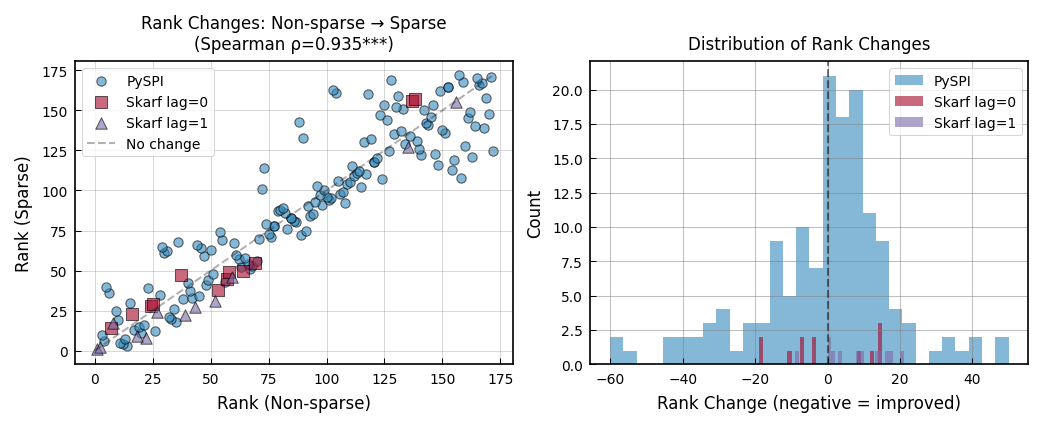

In [38]:
# Visualize rank changes
f, axs = plt.subplots(1, 2, figsize=(2 * PLOTW, 0.8 * PLOTW), layout="constrained")

# Scatter plot: non-sparse rank vs sparse rank
ax = axs[0]
plt.sca(ax)

pyspi_ranks = rank_comparison[rank_comparison['method'] == 'pyspi']
skarf_lag0_ranks = rank_comparison[(rank_comparison['method'] == 'skarf') & (rank_comparison['lag'] == 0)]
skarf_lag1_ranks = rank_comparison[(rank_comparison['method'] == 'skarf') & (rank_comparison['lag'] == 1)]

plt.scatter(pyspi_ranks['rank_nonsparse'], pyspi_ranks['rank_sparse'], 
           alpha=0.6, s=20, c=color_cycle[0], label='PySPI', edgecolors='k', linewidths=0.5)
plt.scatter(skarf_lag0_ranks['rank_nonsparse'], skarf_lag0_ranks['rank_sparse'], 
           alpha=0.6, s=30, c=color_cycle[1], marker='s', label='Skarf lag=0', edgecolors='k', linewidths=0.5)
plt.scatter(skarf_lag1_ranks['rank_nonsparse'], skarf_lag1_ranks['rank_sparse'], 
           alpha=0.6, s=30, c=color_cycle[2], marker='^', label='Skarf lag=1', edgecolors='k', linewidths=0.5)

# Add diagonal line (no change)
max_rank = max(rank_comparison['rank_nonsparse'].max(), rank_comparison['rank_sparse'].max())
plt.plot([0, max_rank], [0, max_rank], 'k--', alpha=0.3, linewidth=1, label='No change')

plt.xlabel('Rank (Non-sparse)', fontsize='medium')
plt.ylabel('Rank (Sparse)', fontsize='medium')
plt.title(f'Rank Changes: Non-sparse → Sparse\n(Spearman ρ={rho:.3f}{get_significance(pval) * "*"})', fontsize='medium')
plt.legend(loc='upper left', fontsize='small')
plt.grid(True, alpha=0.3)

# Histogram of rank changes
ax = axs[1]
plt.sca(ax)

plt.hist(pyspi_ranks['rank_change'], bins=30, alpha=0.6, label='PySPI', color=color_cycle[0])
plt.hist(skarf_lag0_ranks['rank_change'], bins=30, alpha=0.6, label='Skarf lag=0', color=color_cycle[1])
plt.hist(skarf_lag1_ranks['rank_change'], bins=30, alpha=0.6, label='Skarf lag=1', color=color_cycle[2])
plt.axvline(0, color='k', linestyle='--', linewidth=1, alpha=0.5)

plt.xlabel('Rank Change (negative = improved)', fontsize='medium')
plt.ylabel('Count', fontsize='medium')
plt.title('Distribution of Rank Changes', fontsize='medium')
plt.legend(loc='upper right', fontsize='small')

f.savefig(analysis_dir / f"rank_correlation_analysis_{target}.{FORMAT}", bbox_inches="tight")

## Summary Statistics

In [39]:
# Summary table
summary_stats = []

# PySPI (no lag)
for metric in ['r2', 'corr']:
    vals = sparse_cognition[sparse_cognition['method'] == 'pyspi'][f'{metric}_test'].values
    
    summary_stats.append({
        'method': 'pyspi',
        'lag': '-',
        'metric': metric,
        'n': len(vals),
        'median': np.median(vals),
        'mean': np.mean(vals),
        'std': np.std(vals),
        'min': np.min(vals),
        'max': np.max(vals),
    })

# Skarf (separate by lag)
for lag in [0, 1]:
    for metric in ['r2', 'corr']:
        vals = sparse_cognition[(sparse_cognition['method'] == 'skarf') & (sparse_cognition['lag'] == lag)][f'{metric}_test'].values
        
        summary_stats.append({
            'method': 'skarf',
            'lag': lag,
            'metric': metric,
            'n': len(vals),
            'median': np.median(vals),
            'mean': np.mean(vals),
            'std': np.std(vals),
            'min': np.min(vals),
            'max': np.max(vals),
        })

summary_df = pd.DataFrame(summary_stats)
print("\nSummary statistics with 0.8 imposed sparsity:")
summary_df


Summary statistics with 0.8 imposed sparsity:


,method,lag,metric,n,median,mean,std,min,max
0,pyspi,-,r2,2960,0.0060,0.0349,0.0639,-0.0792,0.2701
1,pyspi,-,corr,2960,0.1415,0.1615,0.1601,-0.2240,0.5802
2,skarf,0,r2,240,0.1058,0.0986,0.0717,-0.0504,0.2718
3,skarf,0,corr,240,0.3373,0.3041,0.1536,-0.1004,0.6005
4,skarf,1,r2,240,0.1205,0.1121,0.0747,-0.0330,0.2861
5,skarf,1,corr,240,0.3601,0.3276,0.1533,-0.1078,0.5872


In [40]:
# Save summary to CSV
summary_df.to_csv(analysis_dir / 'sparse_prediction_summary.csv', index=False)
sparse_agg.to_csv(analysis_dir / 'sparse_prediction_aggregated.csv', index=False)

print("\nResults saved to:")
print(f"  {analysis_dir / 'sparse_prediction_summary.csv'}")
print(f"  {analysis_dir / 'sparse_prediction_aggregated.csv'}")


Results saved to:
  /home/aerkent/skarf-experiments/results/hcp_1200_sparse_behav_prediction_analysis/sparse_prediction_summary.csv
  /home/aerkent/skarf-experiments/results/hcp_1200_sparse_behav_prediction_analysis/sparse_prediction_aggregated.csv
